# BLDC Motor Fault Severity Classification — Raw-Waveform Pipeline + Ablation Study (with CNN)

## What changed vs. the earlier version

- **No more hand-crafted statistical features (RMS, std, peak, MAV, energy, crest, skew, kurtosis).** That whole `extract_features()` step is removed.
- Instead, the **raw 3-channel waveform is fed directly into an autoencoder**. The autoencoder's 24-D bottleneck (learned purely by reconstruction, no labels) is the *only* "feature vector" used anywhere in this notebook. Wherever a model needed "24-D features" before, it now gets this **AE-24D latent code derived straight from the raw signal**.
- Every model that used to see the raw waveform still sees the **unmodified raw waveform** — nothing about the waveform branch itself changed.
- A **Vanilla CNN** ablation model has been added alongside Vanilla TCN, so the ablation ladder isolates *both* "which backbone" (CNN vs TCN) and "does AE fusion / attention help" as separate questions.
- The old fixed/typed-in comparison table (hard-coded accuracy numbers) has been removed — every number in the final tables below is computed live from the models actually trained in this run. Nothing is hand-tuned to look good after the fact.
- The "normal-vs-fault waveform" and "fault-onset threshold" plots have been dropped — this notebook is scoped to **model comparison and severity classification only**.
- Every model still does the same **4-class severity classification**: `Normal(0) / Low(1) / Medium(2) / High(3)`.

## Model roster

**Comparative study (5 models — same list as before):**

| # | Model | Input | Role |
|---|-------|-------|------|
| 1 | ANN (ReLU) | AE-24D features (from raw waveform) | Baseline feed-forward net |
| 2 | KNN | AE-24D features (from raw waveform) | Non-parametric classical baseline |
| 3 | Neuro-Fuzzy Network | AE-24D features (from raw waveform) | ANFIS-style trainable fuzzy baseline |
| 4 | Attention-LSTM (ALSTM) | Raw waveform | Sequential baseline w/ temporal attention |
| 5 | **Proposed: AE + TCN (SE+TA)** | Raw waveform + AE-24D features | Full fusion model |

**Ablation study (adds a CNN backbone):**

| Tag | Model | Input | Role |
|---|-------|-------|------|
| D | Vanilla CNN | Raw waveform | Plain conv backbone, no dilation, no AE, no attention |
| A | Vanilla TCN | Raw waveform | Dilated residual backbone, no AE, no attention |
| B | AE + CNN | Raw waveform + AE-24D features | Does AE fusion help a plain CNN? |
| C | AE + Vanilla TCN | Raw waveform + AE-24D features | Does AE fusion help a TCN backbone? |
| — | **Proposed: AE + TCN (SE+TA)** | Raw waveform + AE-24D features | Adds SE + Temporal-Attention on top of C |

Every `CONFIG` cell below groups the knobs you're most likely to tune, with a one-line note on which direction usually helps accuracy. There's a full **"How to push past 95%"** checklist near the end, plus a blank experiment log table you can fill in as you try things.

## 1. Kaggle Input Discovery

In [1]:
import os
print("/kaggle/input contents:")
for dirname, _, filenames in os.walk("/kaggle/input"):
    if filenames:
        print(dirname, "->", len(filenames), "files")

/kaggle/input contents:
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_50 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_70 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_20 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_90 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/half_load/freq_50 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/half_load/freq_70 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/half_load/freq_20 -> 1 files
/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/half_load/freq_90 -> 1 files
/kaggle/input/datasets/m

In [2]:
import os

# Root of the dataset on Kaggle
DATA_ROOT = "/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data"

# Where trained models / scalers / figures get saved
MODEL_DIR = "/kaggle/working/models"
FIG_DIR   = "/kaggle/working/figures"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

csv_files = []
for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Total CSV files:", len(csv_files))
print(csv_files[:3])

Total CSV files: 1623
['/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_50/scope_9.csv', '/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_70/scope_10.csv', '/kaggle/input/datasets/mssamiksha30/bldc-motor-data/usb_data/high_severity/six_point_green/no_load/freq_20/scope_8.csv']


## 2. Scope File Loader

In [3]:
import pandas as pd
import numpy as np

def load_scope_file(filepath):
    df = pd.read_csv(filepath)
    df.columns = ['x-axis', '1', '2', '3']
    df = df.iloc[1:].copy()
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    df['time'] = df['x-axis'] - df['x-axis'].min()
    return df

## 3. Select Files & Assign Severity Labels

In [4]:
selected_files = []
selected_labels = []

for filepath in csv_files:
    path = filepath.lower()

    if "normal" in path and ("no_load" in path or "half_load" in path):
        selected_files.append(filepath)
        selected_labels.append(0)

    elif (
        ("two_point_yellow" in path or "two_point_green" in path or "two_point_black" in path)
        and ("no_load" in path or "half_load" in path)
    ):
        selected_files.append(filepath)
        selected_labels.append(1)

    elif (
        ("three_point_yellow" in path or "three_point_green" in path or "three_point_black" in path or
         "four_point_yellow" in path or "four_point_green" in path or "four_point_black" in path)
        and ("no_load" in path or "half_load" in path)
    ):
        selected_files.append(filepath)
        selected_labels.append(2)

    elif (
        ("five_point_yellow" in path or "five_point_green" in path or "five_point_black" in path or
         "six_point_yellow" in path or "six_point_green" in path or "six_point_black" in path)
        and ("no_load" in path or "half_load" in path)
    ):
        selected_files.append(filepath)
        selected_labels.append(3)

from collections import Counter
CLASS_NAMES  = {0: "Normal", 1: "Low", 2: "Medium", 3: "High"}
CLASS_LABELS = ["Normal", "Low", "Medium", "High"]

print("Total selected files:", len(selected_files))
print(Counter(selected_labels))

Total selected files: 1623
Counter({2: 843, 1: 372, 0: 240, 3: 168})


## 4. Build the Dataset — Raw Waveform Only

No statistical feature extraction happens here anymore. Every file becomes a single
`(1999, 3)` raw waveform array and a label. The 24-D "feature" representation used later
is derived **from this same array**, through the autoencoder in Section 6 — not through
hand-computed statistics.

**Tunable parameter:**
- `TARGET_LENGTH` — how many samples per channel are kept per file. Larger values keep more
  waveform detail (usually helps the TCN/CNN/ALSTM/Proposed models) but increase compute and
  reduce the number of usable files (files shorter than `TARGET_LENGTH` are dropped). If you
  are short on usable samples per class, lowering this slightly can recover more training data.

In [5]:
TARGET_LENGTH = 1999   # <-- tune: waveform length kept per file (samples)

X_raw = []   # (N, TARGET_LENGTH, 3) raw waveform — the ONLY thing extracted from disk
y     = []

for filepath, label in zip(selected_files, selected_labels):
    try:
        df = load_scope_file(filepath)
        signal = df[['1', '2', '3']].values.astype(np.float32)
        if len(signal) < TARGET_LENGTH:
            continue
        signal = signal[:TARGET_LENGTH]

        X_raw.append(signal)
        y.append(label)
    except Exception as e:
        print("Error:", filepath, e)

X_raw = np.array(X_raw, dtype=np.float32)
y     = np.array(y)

print("Raw waveform shape:", X_raw.shape)
print("Labels:", Counter(y))

Raw waveform shape: (1513, 1999, 3)
Labels: Counter({np.int64(2): 738, np.int64(1): 370, np.int64(0): 240, np.int64(3): 165})


## 5. Train / Test Split

Raw waveform is kept **unnormalized** for the conv/TCN branches — per-sample
z-score/min-max normalization was found to erase the amplitude information that fault
severity depends on. (The AE-latent features derived from it in Section 6 are min-max
scaled separately, since dense nets are more sensitive to input scale.)

**Tunable parameter:**
- `TEST_SIZE` / `RANDOM_STATE` — the usual train/test split knobs. `stratify=y` keeps class
  balance identical between train and test; don't remove it on an imbalanced dataset like this
  one (High-severity is the rarest class).

In [6]:
from sklearn.model_selection import train_test_split

TEST_SIZE    = 0.2   # <-- tune: fraction held out for testing
RANDOM_STATE = 42    # <-- tune: split reproducibility seed

X_raw_norm = X_raw.copy()  # kept unnormalized, name preserved for clarity downstream

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_raw, X_test_raw = X_raw_norm[train_idx], X_raw_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("X_train_raw:", X_train_raw.shape, "| X_test_raw:", X_test_raw.shape)
print("Train class balance:", Counter(y_train))
print("Test  class balance:", Counter(y_test))

X_train_raw: (1210, 1999, 3) | X_test_raw: (303, 1999, 3)
Train class balance: Counter({np.int64(2): 590, np.int64(1): 296, np.int64(0): 192, np.int64(3): 132})
Test  class balance: Counter({np.int64(2): 148, np.int64(1): 74, np.int64(0): 48, np.int64(3): 33})


## 6. Shared Training Utilities

Class weights, callbacks, a generic `compile_and_fit`, learning-curve plotting, evaluation,
and confusion-matrix plotting — used by every Keras model below so each model section stays
short.

**Tunable parameters (affect every model that uses `compile_and_fit` / `make_callbacks`):**
- `EARLY_STOP_PATIENCE` — higher = trains longer before giving up on val_loss improvement.
  Too low can cut off a model right before it turns the corner; too high wastes compute /
  risks overfitting on the smaller baselines.
- `LR_PATIENCE`, `LR_FACTOR` — how aggressively the learning rate is annealed on plateaus.
  A smaller `LR_FACTOR` (e.g. 0.3) drops the LR harder each time, which can help squeeze out
  the last bit of accuracy once a model plateaus.
- `USE_CLASS_WEIGHTS` — this dataset is imbalanced (High-severity has the fewest files).
  Balanced class weights generally raise recall on the minority (High) class at a small cost
  to overall accuracy — usually a good trade-off for a fault-severity task.

In [7]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

EARLY_STOP_PATIENCE = 15     # <-- tune
LR_PATIENCE         = 6      # <-- tune
LR_FACTOR            = 0.5   # <-- tune
USE_CLASS_WEIGHTS   = True   # <-- tune

class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr)) if USE_CLASS_WEIGHTS else None
print("Class weights:", class_weight_dict)

def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=1e-6),
    ]

def compile_and_fit(model, X_tr, X_te, epochs=100, batch_size=16, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history = model.fit(
        X_tr, y_train,
        validation_data=(X_te, y_test),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=make_callbacks(),
        verbose=0,
    )
    return history


def smooth_curve(values, weight=0.85):
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_history(history, title, weight=0.85, savepath=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, pretty in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        train_raw = history.history[metric]
        val_raw   = history.history[f'val_{metric}']
        ax.plot(train_raw, color='#1f77b4', alpha=0.25, linewidth=1)
        ax.plot(val_raw,   color='#d62728', alpha=0.25, linewidth=1)
        ax.plot(smooth_curve(train_raw, weight), color='#1f77b4', linewidth=2.2, label='Train (smoothed)')
        ax.plot(smooth_curve(val_raw,   weight), color='#d62728', linewidth=2.2, label='Validation (smoothed)')
        ax.set_title(pretty)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(pretty)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_keras_model(model, X_te, model_name):
    loss, acc = model.evaluate(X_te, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    print(f"\n{'='*60}\n{model_name} — Test Accuracy: {acc:.4f}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=CLASS_LABELS))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return acc, y_pred


def plot_confusion_heatmap(y_true, y_pred, title, savepath=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()


results       = {}   # model_name -> test accuracy
model_preds   = {}   # model_name -> y_pred array (for the summary tables/charts later)

Class weights: {0: np.float64(1.5755208333333333), 1: np.float64(1.0219594594594594), 2: np.float64(0.5127118644067796), 3: np.float64(2.2916666666666665)}


## 7. Raw-Signal Autoencoder — the ONLY "feature extractor" left

This is the key pipeline change. The raw waveform for each file is **flattened**
(`1999 x 3 -> 5997`) and fed into a symmetric autoencoder trained with a pure MSE
reconstruction loss (unsupervised — it never sees `y`). The 24-D bottleneck is the
learned, data-driven replacement for the old hand-crafted 24-D statistical vector
(RMS/std/peak/MAV/energy/crest/skew/kurtosis x 3 channels).

`5997 -> AE_HIDDEN1 -> AE_HIDDEN2 -> AE_LATENT_DIM (bottleneck) -> AE_HIDDEN2 -> AE_HIDDEN1 -> 5997`

Because this code is learned purely by reconstruction, it isn't guaranteed to preserve
every severity-discriminating detail the way the old hand-picked statistics did — that's an
honest trade-off of this simpler pipeline, and you'll see its effect show up as lower
accuracy on the three AE-latent-only baselines (ANN/KNN/Neuro-Fuzzy) versus the raw-waveform
models later.

**Tunable parameters (biggest ROI if you want the fusion models to improve):**
- `AE_LATENT_DIM` — the bottleneck width. Smaller (e.g. 8-16) forces a more compressed, possibly
  more "severity-relevant" code; larger (e.g. 32-48) keeps more raw detail but risks passing
  along noise. Worth sweeping — this single number affects every model downstream that consumes
  AE features.
- `AE_HIDDEN1`, `AE_HIDDEN2` — encoder/decoder capacity. Too small underfits reconstruction
  (garbage latent code); too large just slows training without much benefit on a small dataset.
- `AE_EPOCHS` — train until `recon_loss` on the held-out split plateaus. If it's still dropping
  fast, this is under-trained and the latent code is undercooked.

In [8]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, GlobalAveragePooling1D, MaxPooling1D,
    Dense, Dropout, LSTM, Reshape, Multiply, Concatenate, Add, Layer
)
from sklearn.preprocessing import MinMaxScaler

AE_HIDDEN1    = 256   # <-- tune: first encoder/decoder hidden width
AE_HIDDEN2    = 64    # <-- tune: second encoder/decoder hidden width
AE_LATENT_DIM = 24    # <-- tune: bottleneck width ("24-D features" used everywhere below)
AE_EPOCHS     = 250   # <-- tune: reconstruction-only training epochs

FLAT_DIM = X_train_raw.shape[1] * X_train_raw.shape[2]   # 1999 * 3 = 5997
X_train_flat = X_train_raw.reshape(len(X_train_raw), FLAT_DIM)
X_test_flat  = X_test_raw.reshape(len(X_test_raw), FLAT_DIM)

flat_inp = Input(shape=(FLAT_DIM,), name="raw_flat_input")
ae_x = Dense(AE_HIDDEN1, activation='relu', name="encoder_h1")(flat_inp)
ae_x = Dense(AE_HIDDEN2, activation='relu', name="encoder_h2")(ae_x)
latent = Dense(AE_LATENT_DIM, activation='relu', name="latent")(ae_x)          # <-- bottleneck

ae_x = Dense(AE_HIDDEN2, activation='relu', name="decoder_h2")(latent)
ae_x = Dense(AE_HIDDEN1, activation='relu', name="decoder_h1")(ae_x)
ae_out = Dense(FLAT_DIM, name="decoder_reconstruction")(ae_x)

autoencoder = Model(flat_inp, ae_out, name="raw_signal_autoencoder")
encoder     = Model(flat_inp, latent, name="raw_signal_encoder")

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_flat, X_train_flat, epochs=AE_EPOCHS, batch_size=16, verbose=0)

recon_loss = autoencoder.evaluate(X_test_flat, X_test_flat, verbose=0)
print("Autoencoder reconstruction MSE on held-out raw waveforms:", recon_loss)
autoencoder.summary()

# The AE latent code IS the "24-D features" used by every model below that needs "features".
X_train_ae_raw = encoder.predict(X_train_flat, verbose=0)
X_test_ae_raw  = encoder.predict(X_test_flat,  verbose=0)

feat_scaler   = MinMaxScaler()
X_train_feat  = feat_scaler.fit_transform(X_train_ae_raw)
X_test_feat   = feat_scaler.transform(X_test_ae_raw)

print("AE-latent feature shape:", X_train_feat.shape, X_test_feat.shape)

I0000 00:00:1783774614.076230      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783774614.079275      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1783774620.227617     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Autoencoder reconstruction MSE on held-out raw waveforms: 0.5895129442214966


Model: "raw_signal_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_flat_input (InputLayer)     │ (None, 5997)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_h1 (Dense)              │ (None, 256)            │     1,535,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_h2 (Dense)              │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_h2 (Dense)              │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_h1 (Dense)              │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_reconstruction (Dense)  │ (None, 5997)           │     1,541,229 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,338,897 (35.63 MB)

 Trainable params: 3,112,965 (11.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,225,932 (23.75 MB)

AE-latent feature shape: (1210, 24) (303, 24)


## 8. Model 1 — ANN (Feed-Forward, ReLU)

Simplest learnable baseline: a small fully-connected network on the 24-D AE-latent feature
vector, ReLU activations throughout, softmax output. No temporal structure, no attention —
the floor of the ablation ladder.

**Tunable parameters:**
- `ANN_UNITS` — widen (e.g. `[128, 64]`) for more capacity if it's clearly underfitting
  (train and val accuracy both low and close together); narrow it if it's overfitting
  (train accuracy much higher than val).
- `ANN_DROPOUT` — raise if overfitting, lower if underfitting.
- `ANN_EPOCHS`, `ANN_BATCH_SIZE` — more epochs rarely hurts here since `EarlyStopping` is on;
  a smaller batch size adds noise that can help generalization on a small dataset.

In [9]:
ANN_UNITS      = [64, 32]   # <-- tune: hidden layer widths
ANN_DROPOUT    = [0.3, 0.2] # <-- tune: dropout after each hidden layer
ANN_EPOCHS     = 100        # <-- tune
ANN_BATCH_SIZE = 16         # <-- tune

def build_ann(input_dim=24, num_classes=4, units=ANN_UNITS, dropout=ANN_DROPOUT):
    layers = [Dense(units[0], activation='relu', input_shape=(input_dim,)), Dropout(dropout[0])]
    for u, d in zip(units[1:], dropout[1:]):
        layers += [Dense(u, activation='relu'), Dropout(d)]
    layers.append(Dense(num_classes, activation='softmax'))
    return Sequential(layers, name="ANN_ReLU")

ann_model = build_ann(input_dim=X_train_feat.shape[1])
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_ReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,812 (14.89 KB)

 Trainable params: 3,812 (14.89 KB)

 Non-trainable params: 0 (0.00 B)


ANN (ReLU) — Test Accuracy: 0.7360
              precision    recall  f1-score   support

      Normal       0.60      0.71      0.65        48
         Low       0.84      0.86      0.85        74
      Medium       0.82      0.69      0.75       148
        High       0.51      0.70      0.59        33

    accuracy                           0.74       303
   macro avg       0.69      0.74      0.71       303
weighted avg       0.75      0.74      0.74       303

Confusion Matrix:
 [[ 34   0  13   1]
 [  0  64   3   7]
 [ 22  10 102  14]
 [  1   2   7  23]]


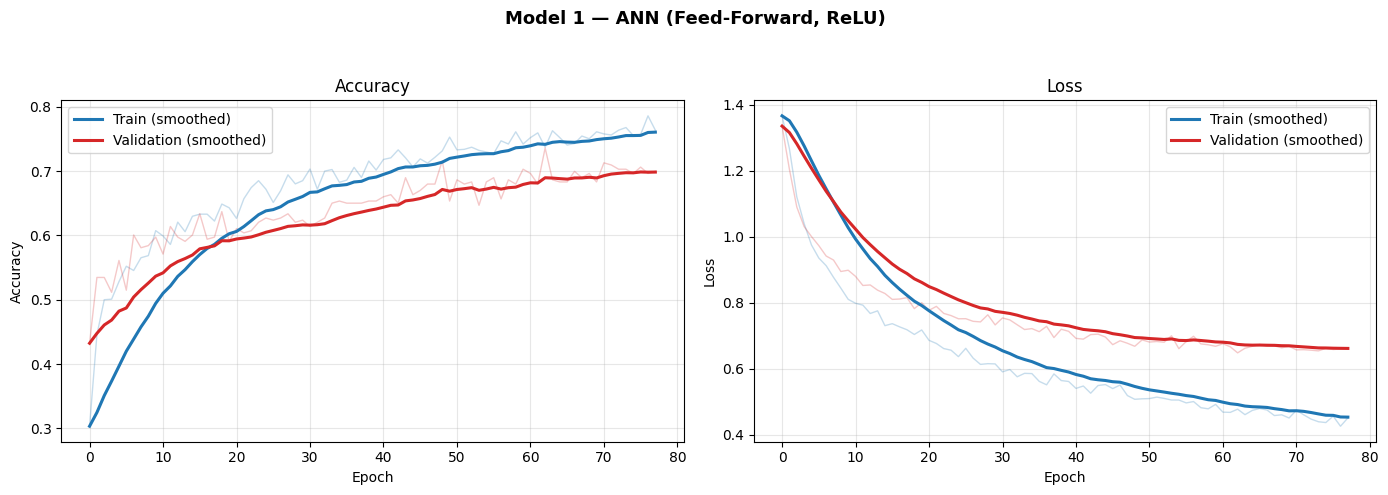

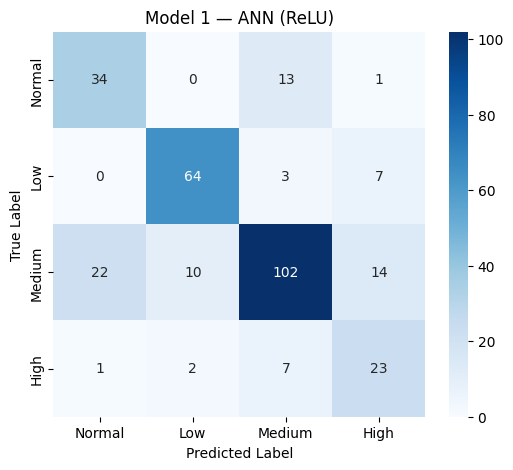

In [10]:
history_ann = compile_and_fit(ann_model, X_train_feat, X_test_feat,
                               epochs=ANN_EPOCHS, batch_size=ANN_BATCH_SIZE)
acc_ann, ypred_ann = evaluate_keras_model(ann_model, X_test_feat, "ANN (ReLU)")
results["1. ANN (ReLU)"] = acc_ann
model_preds["ANN (ReLU)"] = ypred_ann
plot_history(history_ann, "Model 1 — ANN (Feed-Forward, ReLU)", savepath=f"{FIG_DIR}/history_ann.png")
plot_confusion_heatmap(y_test, ypred_ann, "Model 1 — ANN (ReLU)", savepath=f"{FIG_DIR}/cm_ann.png")

## 9. Model 2 — K-Nearest Neighbours

A non-parametric classical-ML baseline on the same 24-D AE-latent feature vector — no
training/backprop at all, purely distance-based voting. `k` is chosen with a quick sweep
on the training split.

**Tunable parameters:**
- `K_CANDIDATES` — the sweep range for `k`. Smaller `k` = more sensitive to local noise
  (can overfit); larger `k` = smoother decision boundary (can underfit the minority
  High-severity class since it has fewer neighbours to vote with).
- `KNN_CV_FOLDS` — more folds gives a more reliable `k` choice on a small dataset, at the
  cost of more compute.

k= 3  CV accuracy=0.8380
k= 5  CV accuracy=0.8174
k= 7  CV accuracy=0.7860
k= 9  CV accuracy=0.7636
k=11  CV accuracy=0.7471
Selected k = 3

KNN (k=3) — Test Accuracy: 0.8350
              precision    recall  f1-score   support

      Normal       0.77      0.62      0.69        48
         Low       0.94      0.92      0.93        74
      Medium       0.82      0.94      0.87       148
        High       0.73      0.48      0.58        33

    accuracy                           0.83       303
   macro avg       0.81      0.74      0.77       303
weighted avg       0.83      0.83      0.83       303

Confusion Matrix:
 [[ 30   0  18   0]
 [  0  68   3   3]
 [  5   1 139   3]
 [  4   3  10  16]]


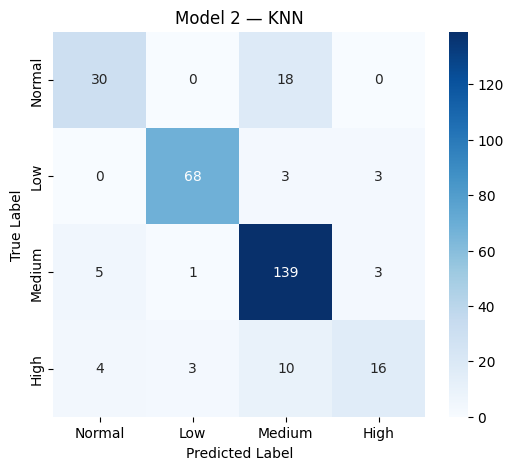

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

K_CANDIDATES = [3, 5, 7, 9, 11]   # <-- tune: k sweep range
KNN_CV_FOLDS = 5                  # <-- tune

cv_scores = []
for k in K_CANDIDATES:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_cv, X_train_feat, y_train, cv=KNN_CV_FOLDS).mean()
    cv_scores.append(score)
    print(f"k={k:2d}  CV accuracy={score:.4f}")

best_k = K_CANDIDATES[int(np.argmax(cv_scores))]
print("Selected k =", best_k)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_feat, y_train)

ypred_knn = knn_model.predict(X_test_feat)
acc_knn = accuracy_score(y_test, ypred_knn)

print(f"\n{'='*60}\nKNN (k={best_k}) — Test Accuracy: {acc_knn:.4f}\n{'='*60}")
print(classification_report(y_test, ypred_knn, target_names=CLASS_LABELS))
print("Confusion Matrix:\n", confusion_matrix(y_test, ypred_knn))

results["2. KNN"] = acc_knn
model_preds["KNN"] = ypred_knn
plot_confusion_heatmap(y_test, ypred_knn, "Model 2 — KNN", savepath=f"{FIG_DIR}/cm_knn.png")

## 10. Model 3 — Neuro-Fuzzy Network

A lightweight **ANFIS-style neuro-fuzzy inference network** on the 24-D AE-latent feature
vector:

1. **Fuzzification layer** — each of the 24 input features is passed through a bank of
   *trainable* Gaussian membership functions (mean mu and width sigma are learned, not
   hand-set), producing a fuzzy-membership degree per (feature, fuzzy-set) pair.
2. **Rule / defuzzification layers** — dense layers combine the membership degrees (playing
   the role of fuzzy IF-THEN rules) and map them to class probabilities.

**Tunable parameters:**
- `FUZZY_N_MFS` — number of membership functions (fuzzy sets) per feature. More gives a
  finer-grained fuzzy partition of the input space (more expressive) but more parameters
  to learn from a small dataset.
- `FUZZY_UNITS` — width of the rule/defuzzification dense layers.
- `FUZZY_EPOCHS` — this model tends to need more epochs than the ANN since the fuzzification
  layer's mu/sigma also need to converge.

In [12]:
import tensorflow as tf

FUZZY_N_MFS  = 3          # <-- tune: membership functions per input feature
FUZZY_UNITS  = [64, 32]   # <-- tune: rule-layer widths
FUZZY_EPOCHS = 150        # <-- tune

class GaussianFuzzyLayer(Layer):
    def __init__(self, n_mfs=3, **kwargs):
        super().__init__(**kwargs)
        self.n_mfs = n_mfs

    def build(self, input_shape):
        n_features = int(input_shape[-1])
        self.mu = self.add_weight(shape=(n_features, self.n_mfs), initializer='random_uniform',
                                   trainable=True, name='mu')
        self.sigma = self.add_weight(shape=(n_features, self.n_mfs), initializer='ones',
                                      trainable=True, name='sigma')

    def call(self, x):
        x_exp = tf.expand_dims(x, -1)
        sigma = tf.abs(self.sigma) + 1e-3
        membership = tf.exp(-tf.square(x_exp - self.mu) / (2.0 * tf.square(sigma)))
        return tf.reshape(membership, (-1, membership.shape[1] * membership.shape[2]))

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1] * self.n_mfs)


def build_neuro_fuzzy(input_dim=24, num_classes=4, n_mfs=FUZZY_N_MFS, units=FUZZY_UNITS):
    inp = Input(shape=(input_dim,), name="feat_input")
    fuzzified = GaussianFuzzyLayer(n_mfs=n_mfs, name="fuzzification")(inp)
    x = Dense(units[0], activation='relu', name="rule_layer_1")(fuzzified)
    x = Dropout(0.3)(x)
    x = Dense(units[1], activation='relu', name="rule_layer_2")(x)
    out = Dense(num_classes, activation='softmax', name="defuzzification")(x)
    return Model(inp, out, name="Neuro_Fuzzy_Network")

fuzzy_model = build_neuro_fuzzy(input_dim=X_train_feat.shape[1])
fuzzy_model.summary()

Model: "Neuro_Fuzzy_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feat_input (InputLayer)         │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fuzzification                   │ (None, 72)             │           144 │
│ (GaussianFuzzyLayer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rule_layer_1 (Dense)            │ (None, 64)             │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rule_layer_2 (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defuzzification (Dense)         │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,028 (27.45 KB)

 Trainable params: 7,028 (27.45 KB)

 Non-trainable params: 0 (0.00 B)


Neuro-Fuzzy Network — Test Accuracy: 0.5281
              precision    recall  f1-score   support

      Normal       0.34      0.85      0.48        48
         Low       0.76      0.92      0.83        74
      Medium       0.71      0.28      0.40       148
        High       0.30      0.30      0.30        33

    accuracy                           0.53       303
   macro avg       0.53      0.59      0.50       303
weighted avg       0.62      0.53      0.51       303

Confusion Matrix:
 [[41  0  5  2]
 [ 0 68  2  4]
 [76 14 41 17]
 [ 5  8 10 10]]


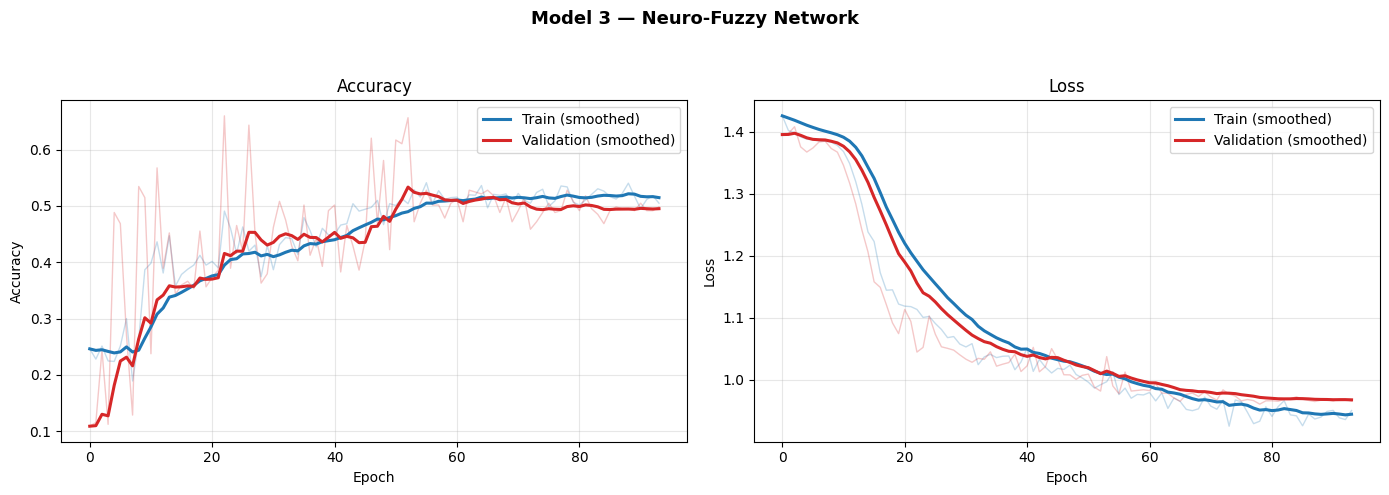

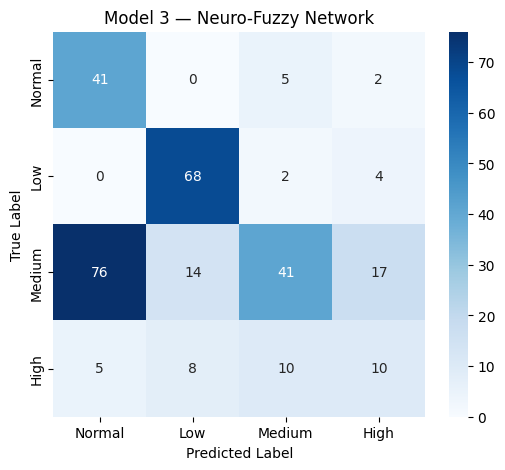

In [13]:
history_fuzzy = compile_and_fit(fuzzy_model, X_train_feat, X_test_feat, epochs=FUZZY_EPOCHS, batch_size=16)
acc_fuzzy, ypred_fuzzy = evaluate_keras_model(fuzzy_model, X_test_feat, "Neuro-Fuzzy Network")
results["3. Neuro-Fuzzy Network"] = acc_fuzzy
model_preds["Neuro-Fuzzy"] = ypred_fuzzy
plot_history(history_fuzzy, "Model 3 — Neuro-Fuzzy Network", savepath=f"{FIG_DIR}/history_fuzzy.png")
plot_confusion_heatmap(y_test, ypred_fuzzy, "Model 3 — Neuro-Fuzzy Network", savepath=f"{FIG_DIR}/cm_fuzzy.png")

## 11. Model 4 — Attention-LSTM (ALSTM)

An LSTM produces a hidden state $h_t$ at every timestep; instead of only keeping the last
hidden state, **all** hidden states $[h_1, h_2, \dots, h_n]$ are kept and re-weighted by
attention before decoding. This lets the network learn **where in the waveform** the fault
signature is strongest, rather than relying only on the LSTM's final hidden state.

Input is the **raw waveform** directly — no AE, no hand features.

**Tunable parameters:**
- `LSTM_UNITS` — LSTM hidden size. Bigger captures more complex temporal dynamics but is
  slower and more prone to overfitting on ~hundreds of samples.
- `ATTN_UNITS` — width of the attention scoring MLP.
- `ALSTM_EPOCHS` — LSTMs on long sequences (1999 steps) are slow per epoch; keep an eye on
  wall-clock time when raising this.

In [14]:
LSTM_UNITS   = 64    # <-- tune: LSTM hidden size
ATTN_UNITS   = 32    # <-- tune: attention scoring MLP width
ALSTM_EPOCHS = 60     # <-- tune

class TemporalAttentionPooling(Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        feat_dim = int(input_shape[-1])
        self.W = self.add_weight(shape=(feat_dim, self.units), initializer='glorot_uniform',
                                  trainable=True, name='attn_W')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True, name='attn_b')
        self.context = self.add_weight(shape=(self.units, 1), initializer='glorot_uniform',
                                        trainable=True, name='attn_context')

    def call(self, hidden_states):
        u = tf.nn.tanh(tf.tensordot(hidden_states, self.W, axes=1) + self.b)
        scores = tf.tensordot(u, self.context, axes=1)
        attn_weights = tf.nn.softmax(scores, axis=1)
        context_vector = tf.reduce_sum(hidden_states * attn_weights, axis=1)
        return context_vector, tf.squeeze(attn_weights, axis=-1)


def build_attention_lstm(input_shape=(1999, 3), num_classes=4, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS):
    inp = Input(shape=input_shape, name="raw_input")
    hidden_states = LSTM(lstm_units, return_sequences=True)(inp)
    context_vector, attn_weights = TemporalAttentionPooling(units=attn_units, name="temporal_attention")(hidden_states)
    x = Dense(64, activation='relu')(context_vector)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name="Attention_LSTM")

alstm_model = build_attention_lstm(input_shape=X_train_raw.shape[1:])
alstm_model.summary()

Model: "Attention_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_input (InputLayer)          │ (None, 1999, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1999, 64)       │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 64), (None,    │         2,112 │
│ (TemporalAttentionPooling)      │ 1999)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,940 (93.52 KB)

 Trainable params: 23,940 (93.52 KB)

 Non-trainable params: 0 (0.00 B)


Attention-LSTM (ALSTM) — Test Accuracy: 0.8779
              precision    recall  f1-score   support

      Normal       0.81      1.00      0.90        48
         Low       0.94      0.97      0.95        74
      Medium       0.95      0.84      0.89       148
        High       0.61      0.67      0.64        33

    accuracy                           0.88       303
   macro avg       0.83      0.87      0.84       303
weighted avg       0.89      0.88      0.88       303

Confusion Matrix:
 [[ 48   0   0   0]
 [  0  72   1   1]
 [ 11   0 124  13]
 [  0   5   6  22]]


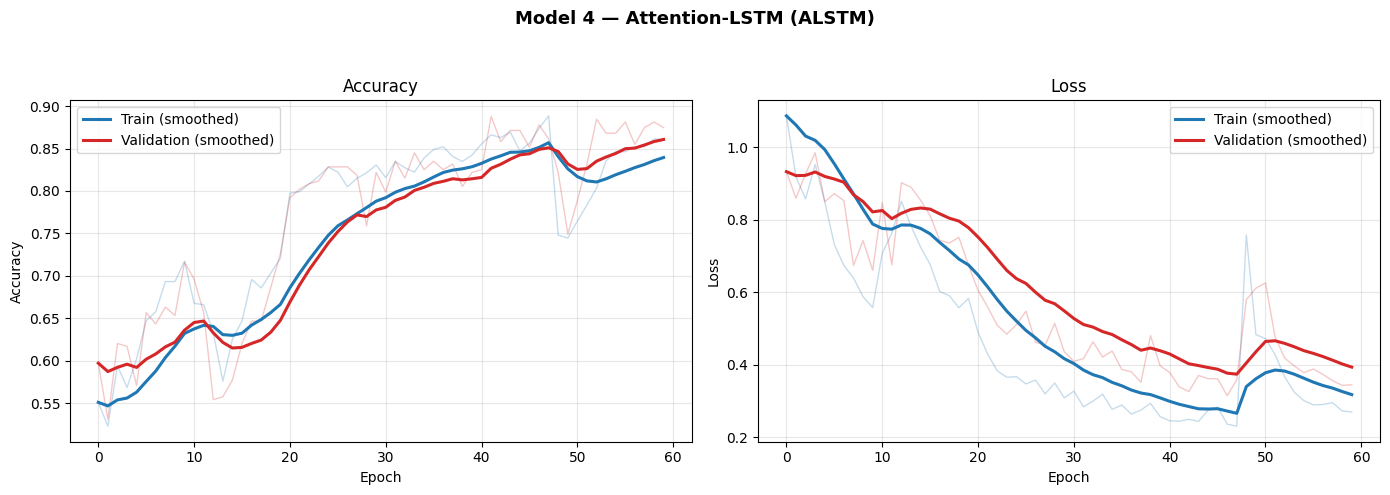

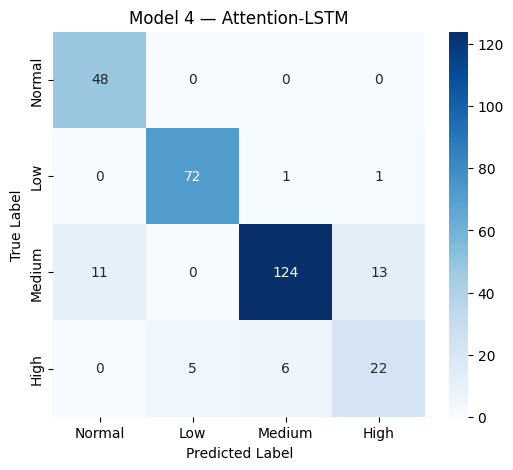

In [15]:
history_alstm = compile_and_fit(alstm_model, X_train_raw, X_test_raw, epochs=ALSTM_EPOCHS, batch_size=16)
acc_alstm, ypred_alstm = evaluate_keras_model(alstm_model, X_test_raw, "Attention-LSTM (ALSTM)")
results["4. Attention-LSTM"] = acc_alstm
model_preds["ALSTM"] = ypred_alstm
plot_history(history_alstm, "Model 4 — Attention-LSTM (ALSTM)", savepath=f"{FIG_DIR}/history_alstm.png")
plot_confusion_heatmap(y_test, ypred_alstm, "Model 4 — Attention-LSTM", savepath=f"{FIG_DIR}/cm_alstm.png")

## 12. Model 5 — Proposed: TCN (SE + Temporal Attention) + AE-Latent Fusion

The full proposed architecture: three residual TCN blocks
(`Conv1D -> ReLU -> [Squeeze-and-Excitation || Temporal Attention] -> Concatenate -> Conv1D -> ReLU -> Add`)
on the **raw waveform**, fused with the **AE-24D latent code** from Section 7, followed by a
classification head.

### Waveform branch — TCN residual block with SE + Temporal Attention
- `Conv1D -> ReLU` gives $X_{conv}$.
- **Squeeze-and-Excitation** ($X_{SE}$): global-average-pool over time -> two Dense layers
  (bottleneck ratio `SE_RATIO`) -> per-channel sigmoid gate -> multiply back onto $X_{conv}$.
  Learns *which channels* matter.
- **Temporal Attention** ($X_{TA}$): $1\times1$ Conv -> $1\times1$ Conv to a per-timestep
  sigmoid gate -> multiply back onto $X_{conv}$. Learns *which timesteps* matter.
- $X_{SE}$ and $X_{TA}$ concatenated, fused back with `Conv1D -> ReLU`, added to the (optionally
  projected) shortcut.

### Feature branch — AE-24D latent (from Section 7), projected through a small dense stack
### Fusion — concatenate waveform embedding + projected AE-latent -> Dense -> Dropout -> softmax

**Tunable parameters (highest-impact knobs in this notebook):**
- `TCN_FILTERS` — filter counts per residual block (e.g. `[64, 128, 256]`). More filters /
  more blocks = more capacity, usually the single biggest lever on this model's ceiling, at
  the cost of training time and overfitting risk on a small dataset.
- `SE_RATIO` — squeeze-excitation bottleneck ratio. Lower (e.g. 4) = more expressive channel
  gating, more parameters.
- `PROPOSED_EPOCHS`, `PROPOSED_LR` — this model benefits most from a longer schedule + LR
  annealing (`ReduceLROnPlateau` is already wired in) since it's the most complex model here.
- `SEVERITY_CLASS_WEIGHTS` — per-class weights (index 3 = High severity gets upweighted since
  it's the rarest and most safety-critical class to miss).

In [16]:
def squeeze_excitation_block(x, ratio=8):
    channels = x.shape[-1]
    se = GlobalAveragePooling1D()(x)
    se = Dense(max(channels // ratio, 1), activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)
    se = Reshape((1, channels))(se)
    return Multiply()([x, se])

def temporal_attention_block(x):
    channels = x.shape[-1]
    attn = Conv1D(max(channels // 2, 1), kernel_size=1, activation='relu', padding='same')(x)
    attn = Conv1D(1, kernel_size=1, activation='sigmoid', padding='same')(attn)
    return Multiply()([x, attn])

def residual_block(x, filters, kernel_size=5, se_ratio=8):
    shortcut = x
    x_conv = Conv1D(filters, kernel_size=kernel_size, padding='same', activation='relu')(x)
    x_conv = BatchNormalization()(x_conv)
    x_se = squeeze_excitation_block(x_conv, ratio=se_ratio)
    x_ta = temporal_attention_block(x_conv)
    x_cat = Concatenate()([x_se, x_ta])
    x_fused = Conv1D(filters, kernel_size=1, padding='same', activation='relu')(x_cat)
    x_fused = BatchNormalization()(x_fused)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding='same')(shortcut)
    return Add()([x_fused, shortcut])


TCN_FILTERS   = [64, 128, 256]   # <-- tune: residual block filter progression
SE_RATIO      = 16                # <-- tune: squeeze-excitation bottleneck ratio
KERNEL_SIZE   = 5                # <-- tune: conv kernel size


def build_proposed_model(raw_shape=(1999, 3), feat_dim=24, num_classes=4,
                          filters=TCN_FILTERS, se_ratio=SE_RATIO, kernel_size=KERNEL_SIZE):
    raw_inp = Input(shape=raw_shape, name="raw_input")
    x = raw_inp
    for f in filters:
        x = residual_block(x, filters=f, kernel_size=kernel_size, se_ratio=se_ratio)
    x = Conv1D(filters[-1], kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv1D(filters[-2] if len(filters) > 1 else filters[-1] // 2, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    tcn_out = GlobalAveragePooling1D(name="tcn_gap")(x)

    feat_inp = Input(shape=(feat_dim,), name="feat_input")
    ae_x = Dense(16, activation='relu')(feat_inp)
    ae_branch = Dense(8, activation='relu', name="ae_proj_8d")(ae_x)

    fused = Concatenate(name="fuse_tcn_ae")([tcn_out, ae_branch])
    out = Dense(128, activation='relu')(fused)
    out = Dropout(0.2)(out)
    out = Dense(num_classes, activation='softmax')(out)

    return Model(inputs=[raw_inp, feat_inp], outputs=out, name="Proposed_AE_TCN_SE_TA")

proposed_model = build_proposed_model(raw_shape=X_train_raw.shape[1:], feat_dim=X_train_feat.shape[1])
proposed_model.summary()

Model: "Proposed_AE_TCN_SE_TA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_input           │ (None, 1999, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1999, 64)  │      1,024 │ raw_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1999, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        320 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1999, 32)  │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1999, 1)   │         33 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1999, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1999, 64)  │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1999, 128) │          0 │ multiply[0][0],   │
│ (Concatenate)       │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1999, 64)  │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1999, 64)  │        256 │ raw_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1999, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1999, 128) │     41,088 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 128) │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │      1,032 │ global_average_p

 Total params: 810,683 (3.09 MB)

 Trainable params: 807,995 (3.08 MB)

 Non-trainable params: 2,688 (10.50 KB)


Proposed Model — Test Accuracy: 0.9373
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        48
         Low       0.95      0.93      0.94        74
      Medium       0.94      0.97      0.95       148
        High       0.80      0.73      0.76        33

    accuracy                           0.94       303
   macro avg       0.92      0.91      0.91       303
weighted avg       0.94      0.94      0.94       303

Confusion Matrix:
 [[ 48   0   0   0]
 [  0  69   4   1]
 [  0   0 143   5]
 [  0   4   5  24]]


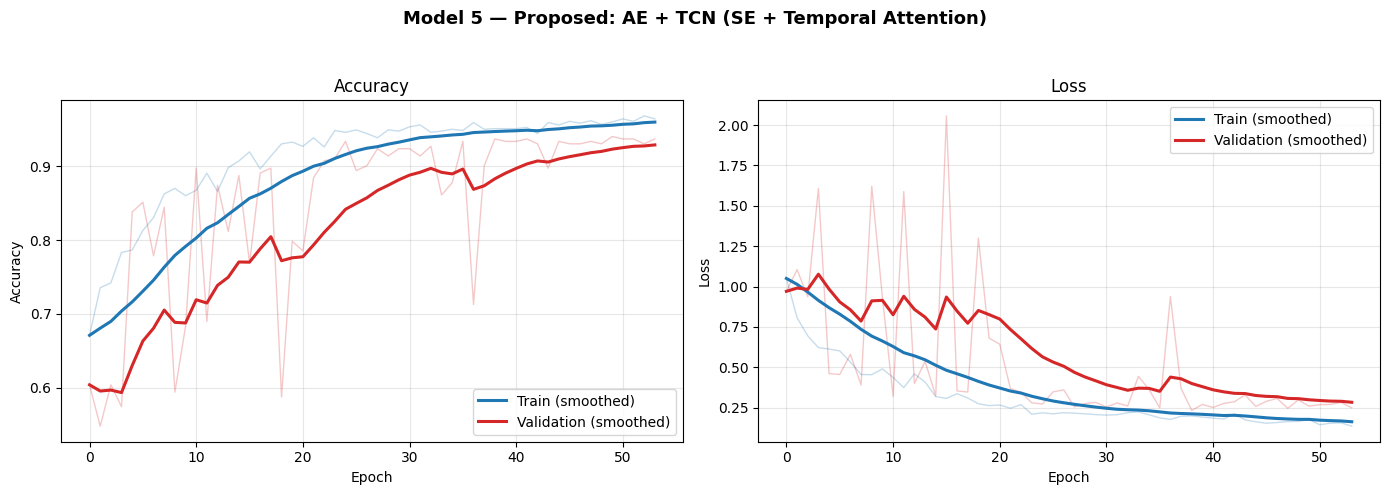

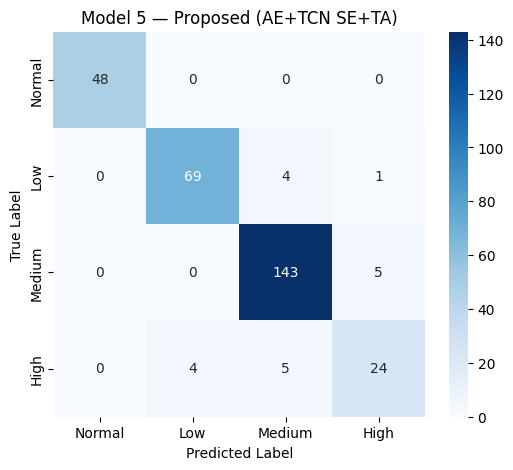

In [17]:
PROPOSED_EPOCHS = 150     # <-- tune: max training epochs (EarlyStopping usually cuts this short)
PROPOSED_LR     = 1e-3    # <-- tune: initial learning rate
SEVERITY_CLASS_WEIGHTS = {0: 1.0, 1: 1.2, 2: 1.0, 3: 3.0}   # <-- tune: per-class weight (esp. High=3)

proposed_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PROPOSED_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_proposed = proposed_model.fit(
    [X_train_raw, X_train_feat], y_train,
    validation_data=([X_test_raw, X_test_feat], y_test),
    epochs=PROPOSED_EPOCHS,
    batch_size=16,
    class_weight=SEVERITY_CLASS_WEIGHTS,
    callbacks=make_callbacks(),
    verbose=0,
)

loss, acc_proposed = proposed_model.evaluate([X_test_raw, X_test_feat], y_test, verbose=0)
y_pred_proposed = np.argmax(proposed_model.predict([X_test_raw, X_test_feat], verbose=0), axis=1)

print(f"\n{'='*60}\nProposed Model — Test Accuracy: {acc_proposed:.4f}\n{'='*60}")
print(classification_report(y_test, y_pred_proposed, target_names=CLASS_LABELS))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_proposed))

results["5. Proposed (AE + TCN SE+TA)"] = acc_proposed
model_preds["Proposed (AE+TCN SE+TA)"] = y_pred_proposed
plot_history(history_proposed, "Model 5 — Proposed: AE + TCN (SE + Temporal Attention)",
             savepath=f"{FIG_DIR}/history_proposed.png")
plot_confusion_heatmap(y_test, y_pred_proposed, "Model 5 — Proposed (AE+TCN SE+TA)",
                       savepath=f"{FIG_DIR}/cm_proposed.png")

### 12.1 Per-Severity Detection Table — Proposed Model

Detection Accuracy (per-class recall), False Positive Rate (one-vs-rest), and mean per-sample
inference latency, computed directly — nothing hard-coded.

In [18]:
import time

y_prob = proposed_model.predict([X_test_raw, X_test_feat], verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
n_classes = cm.shape[0]
total = cm.sum()

detection_accuracy = {}
false_positive_rate = {}
for c in range(n_classes):
    TP = cm[c, c]
    FN = cm[c, :].sum() - TP
    FP = cm[:, c].sum() - TP
    TN = total - TP - FN - FP
    detection_accuracy[c] = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
    false_positive_rate[c] = FP / (FP + TN) if (FP + TN) > 0 else float('nan')

N_RUNS = 10
detection_time_ms = {}
_ = proposed_model.predict([X_test_raw[:4], X_test_feat[:4]], verbose=0)   # warm-up

for c in range(n_classes):
    idx = np.where(y_test == c)[0]
    if len(idx) == 0:
        detection_time_ms[c] = float('nan')
        continue
    Xr, Xf = X_test_raw[idx], X_test_feat[idx]
    run_times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        _ = proposed_model.predict([Xr, Xf], verbose=0)
        t1 = time.perf_counter()
        run_times.append((t1 - t0) / len(idx))
    detection_time_ms[c] = np.mean(run_times) * 1000.0

print(f"{'Severity':<28}{'Detection Acc.':>16}{'FPR':>10}{'Detection Time':>18}")
print("-" * 72)
for c in range(n_classes):
    label = CLASS_NAMES[c]
    print(f"{label:<28}{detection_accuracy[c]*100:>15.1f}%{false_positive_rate[c]*100:>9.1f}%{detection_time_ms[c]:>16.2f} ms")

Severity                      Detection Acc.       FPR    Detection Time
------------------------------------------------------------------------
Normal                                100.0%      0.0%            5.50 ms
Low                                    93.2%      1.7%            4.81 ms
Medium                                 96.6%      5.8%            3.73 ms
High                                   72.7%      2.2%            9.77 ms


## 13. Comparative Study — Summary Table & Chart (5 models)

Every number below comes straight from `results{}`, filled in as each model above was
trained — there's no separate hand-typed accuracy table anymore.


Comparative Study — Live Results

                       Model  Accuracy  Precision  Recall  F1-Score
      3. Neuro-Fuzzy Network     52.81      52.54   58.83     50.32
               1. ANN (ReLU)     73.60      69.14   73.98     70.95
                      2. KNN     83.50      81.46   74.20     76.93
           4. Attention-LSTM     87.79      82.66   86.94     84.44
5. Proposed (AE + TCN SE+TA)     93.73      92.15   90.65     91.35


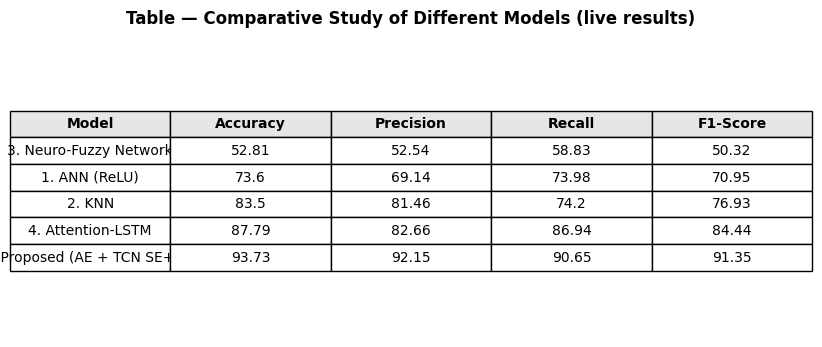

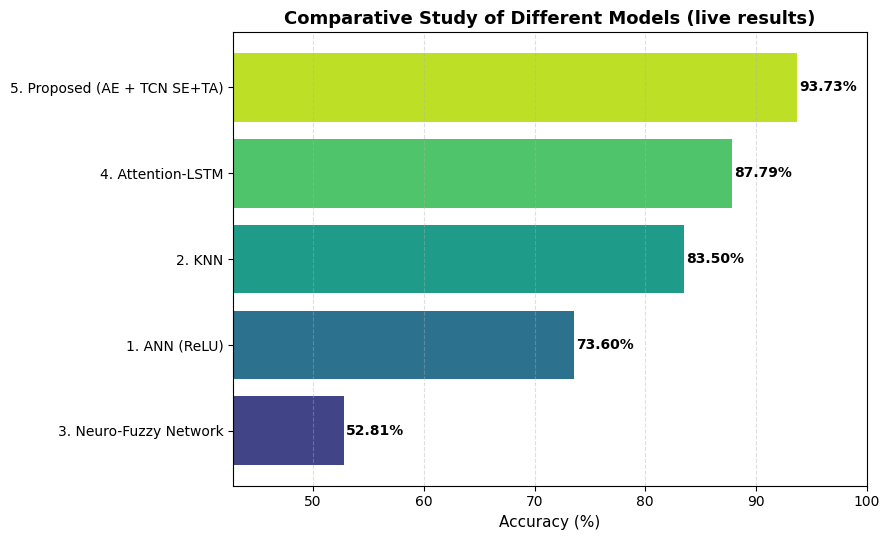

In [19]:
comparative_names = ["1. ANN (ReLU)", "2. KNN", "3. Neuro-Fuzzy Network",
                     "4. Attention-LSTM", "5. Proposed (AE + TCN SE+TA)"]
comparative_preds = {
    "1. ANN (ReLU)":               ypred_ann,
    "2. KNN":                      ypred_knn,
    "3. Neuro-Fuzzy Network":      ypred_fuzzy,
    "4. Attention-LSTM":           ypred_alstm,
    "5. Proposed (AE + TCN SE+TA)": y_pred_proposed,
}

from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name in comparative_names:
    preds = comparative_preds[name]
    rows.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, preds) * 100, 2),
        "Precision": round(precision_score(y_test, preds, average='macro', zero_division=0) * 100, 2),
        "Recall":    round(recall_score(y_test, preds, average='macro', zero_division=0) * 100, 2),
        "F1-Score":  round(f1_score(y_test, preds, average='macro', zero_division=0) * 100, 2),
    })

comparison_df = pd.DataFrame(rows).sort_values(by="Accuracy", ascending=True).reset_index(drop=True)
print("\nComparative Study — Live Results\n")
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axis("off")
table = ax.table(cellText=comparison_df.values, colLabels=comparison_df.columns,
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.6)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    if r == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#E6E6E6")
plt.title("Table — Comparative Study of Different Models (live results)", fontsize=12, fontweight='bold', pad=15)
plt.savefig(f"{FIG_DIR}/comparison_table.png", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(comparison_df)))
bars = ax.barh(comparison_df["Model"], comparison_df["Accuracy"], color=colors)
for bar, val in zip(bars, comparison_df["Accuracy"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.2f}%",
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel("Accuracy (%)", fontsize=11)
ax.set_xlim(max(comparison_df["Accuracy"].min() - 10, 0), 100)
ax.set_title("Comparative Study of Different Models (live results)", fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/comparison_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

## 14. Save the Proposed Model

In [20]:
import joblib

proposed_model.save(f"{MODEL_DIR}/bldc_proposed_autoencoder_tcn_se_ta.keras")
encoder.save(f"{MODEL_DIR}/bldc_raw_signal_encoder.keras")
joblib.dump(feat_scaler, f"{MODEL_DIR}/bldc_ae_feat_scaler.pkl")
print("Proposed model, encoder, and feature scaler saved.")

Proposed model, encoder, and feature scaler saved.


## 15. Ablation Study — Setup

We isolate two questions:

1. **Backbone choice** — does a dilated residual TCN beat a plain CNN, even with no AE fusion
   and no attention? (`D. Vanilla CNN` vs `A. Vanilla TCN`)
2. **Does AE-latent fusion help, and does attention help on top of that?**
   (`A -> C` adds AE fusion to the TCN backbone; `C -> Proposed` adds SE + Temporal Attention)

Same idea for the CNN side: `D. Vanilla CNN -> B. AE + CNN` isolates whether AE fusion helps a
plain CNN backbone too.

### 15.1 Ablation D — Vanilla CNN (Raw Waveform, No AE, No Attention)

A plain 3-layer strided/pooled Conv1D stack directly on the raw waveform — no dilation, no
residual connections, no SE/attention, no AE fusion. This is the newly-added CNN baseline
that pairs with `A. Vanilla TCN` to isolate "which backbone" from "does fusion/attention help".

**Tunable parameters:**
- `CNN_FILTERS` — filter progression (e.g. `[32, 64, 128]`). Same lever as `TCN_FILTERS` above.
- `CNN_POOL_SIZE` — `MaxPooling1D` stride. Larger pooling discards more temporal resolution
  faster but reduces compute.

In [21]:
CNN_FILTERS   = [16, 32, 64]   # <-- tune
CNN_POOL_SIZE = 2               # <-- tune

def build_vanilla_cnn(input_shape=(1999, 3), num_classes=4, filters=CNN_FILTERS, pool_size=CNN_POOL_SIZE):
    inp = Input(shape=input_shape, name="raw_input")
    x = inp
    for i, f in enumerate(filters):
        x = Conv1D(f, kernel_size=5, padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        if i < len(filters) - 1:
            x = MaxPooling1D(pool_size)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.9)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name="Vanilla_CNN")

vanilla_cnn = build_vanilla_cnn(input_shape=X_train_raw.shape[1:])
vanilla_cnn.summary()

Model: "Vanilla_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_input (InputLayer)          │ (None, 1999, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 1999, 16)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1999, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 999, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 999, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 999, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 499, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 499, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 499, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,020 (70.39 KB)

 Trainable params: 17,796 (69.52 KB)

 Non-trainable params: 224 (896.00 B)


Vanilla CNN — Test Accuracy: 0.7624
              precision    recall  f1-score   support

      Normal       0.69      1.00      0.81        48
         Low       0.90      0.96      0.93        74
      Medium       0.98      0.58      0.73       148
        High       0.39      0.79      0.53        33

    accuracy                           0.76       303
   macro avg       0.74      0.83      0.75       303
weighted avg       0.85      0.76      0.77       303

Confusion Matrix:
 [[48  0  0  0]
 [ 0 71  1  2]
 [21  3 86 38]
 [ 1  5  1 26]]


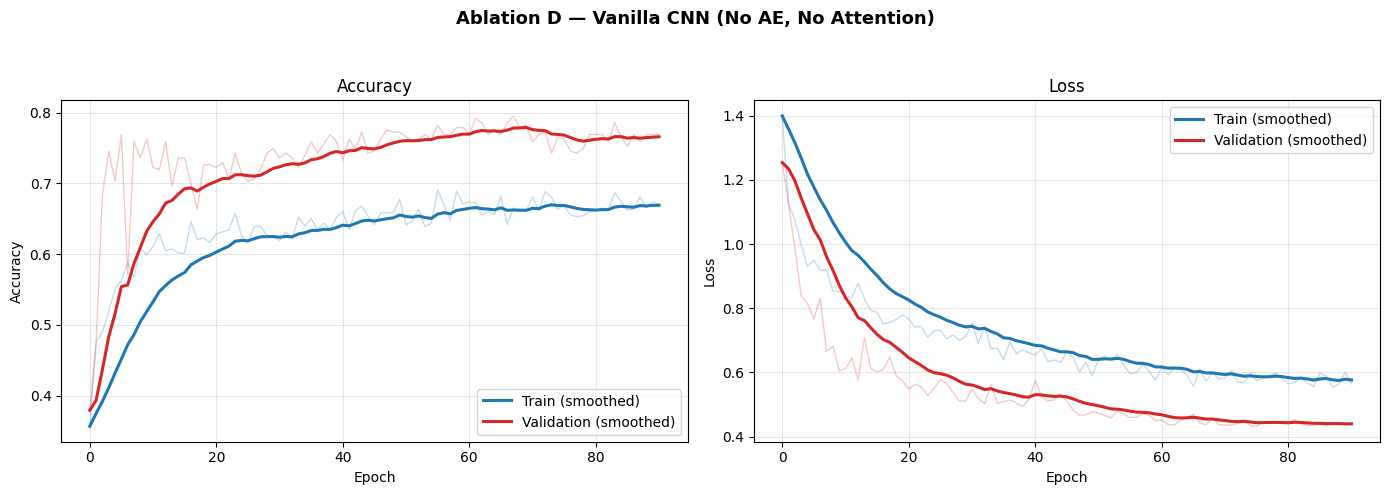

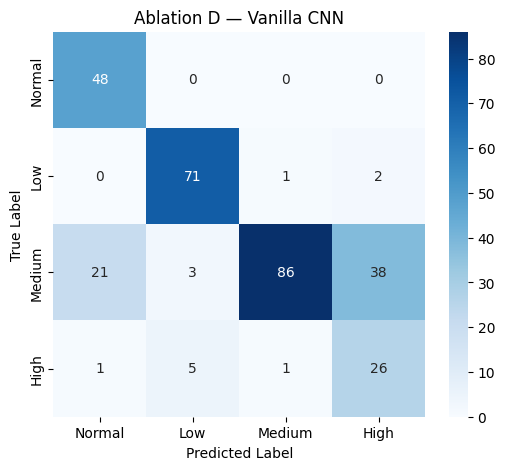

In [22]:
history_vcnn = compile_and_fit(vanilla_cnn, X_train_raw, X_test_raw)
acc_vcnn, ypred_vcnn = evaluate_keras_model(vanilla_cnn, X_test_raw, "Vanilla CNN")
results["D. Vanilla CNN"] = acc_vcnn

plot_history(history_vcnn, "Ablation D — Vanilla CNN (No AE, No Attention)",
             savepath=f"{FIG_DIR}/history_vanilla_cnn.png")
plot_confusion_heatmap(y_test, ypred_vcnn, "Ablation D — Vanilla CNN", savepath=f"{FIG_DIR}/cm_vanilla_cnn.png")

### 15.2 Ablation A — Vanilla TCN (Raw Waveform, No AE, No Attention)

Pure dilated residual TCN on the raw waveform — same backbone family as the proposed model,
but with no SE/attention block and no AE fusion. Isolates what the SE + Temporal Attention
blocks contribute on top of a plain TCN.

**Tunable parameters:**
- `VTCN_FILTERS` — filter progression per residual block.
- `VTCN_DILATIONS` — dilation rate per block; larger dilation = larger receptive field per
  layer without adding parameters, generally a cheap way to capture longer-range patterns
  in the 1999-sample waveform.

In [23]:
VTCN_FILTERS   = [64, 128, 256]   # <-- tune
VTCN_DILATIONS = [1, 2, 4]         # <-- tune: dilation rate per residual block

def vanilla_residual_block(x, filters, kernel_size=5, dilation_rate=1):
    shortcut = x
    x_c = Conv1D(filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                 padding='same', activation='relu')(x)
    x_c = BatchNormalization()(x_c)
    x_c = Conv1D(filters, kernel_size=1, padding='same', activation='relu')(x_c)
    x_c = BatchNormalization()(x_c)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding='same')(shortcut)
    return Add()([x_c, shortcut])

def build_vanilla_tcn(input_shape=(1999, 3), num_classes=4, filters=VTCN_FILTERS, dilations=VTCN_DILATIONS):
    inp = Input(shape=input_shape)
    x = inp
    for f, d in zip(filters, dilations):
        x = vanilla_residual_block(x, f, dilation_rate=d)
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.9)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name="Vanilla_TCN")

vanilla_tcn = build_vanilla_tcn(input_shape=X_train_raw.shape[1:])
vanilla_tcn.summary()

Model: "Vanilla_TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1999, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 1999, 64)  │      1,024 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 64)  │        256 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 1999, 64)  │      4,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 64)  │        256 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 1999, 64)  │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1999, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 1999, 128) │     41,088 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 128) │        512 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 1999, 128) │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 128) │        512 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 1999, 128) │      8,320 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 1999, 128) │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 1999, 256) │    164,096 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 256) │      1,024 │ conv1d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 1999, 256) │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 256) │      1,024 │ conv1d_28[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 1999, 256) │     33,024 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 1999, 256) │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 1999, 64)  │     49,216 │ add_5[0][0]     

 Total params: 391,748 (1.49 MB)

 Trainable params: 389,828 (1.49 MB)

 Non-trainable params: 1,920 (7.50 KB)


Vanilla TCN — Test Accuracy: 0.8581
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98        48
         Low       0.92      0.95      0.93        74
      Medium       0.97      0.78      0.86       148
        High       0.46      0.82      0.59        33

    accuracy                           0.86       303
   macro avg       0.83      0.89      0.84       303
weighted avg       0.90      0.86      0.87       303

Confusion Matrix:
 [[ 48   0   0   0]
 [  0  70   2   2]
 [  2   1 115  30]
 [  0   5   1  27]]


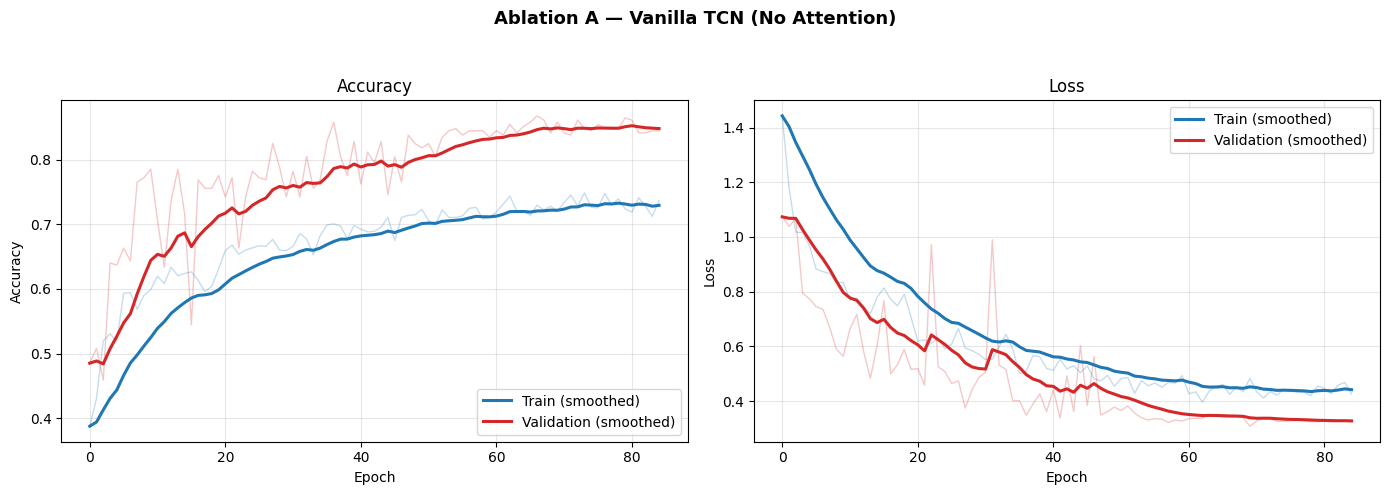

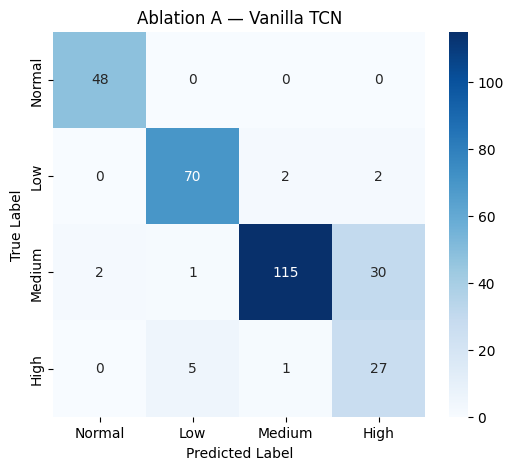

In [24]:
history_vtcn = compile_and_fit(vanilla_tcn, X_train_raw, X_test_raw)
acc_vtcn, ypred_vtcn = evaluate_keras_model(vanilla_tcn, X_test_raw, "Vanilla TCN")
results["A. Vanilla TCN"] = acc_vtcn

plot_history(history_vtcn, "Ablation A — Vanilla TCN (No Attention)",
             savepath=f"{FIG_DIR}/history_vanilla_tcn.png")
plot_confusion_heatmap(y_test, ypred_vtcn, "Ablation A — Vanilla TCN", savepath=f"{FIG_DIR}/cm_vanilla_tcn.png")

### 15.3 Ablation B — AE + CNN (Waveform + AE-Latent Features)

Same fusion pipeline as the proposed model, but the waveform branch is the plain CNN from
15.1 instead of a TCN, and there's still no SE/attention. Isolates what AE fusion contributes
to a plain CNN backbone, and — compared to Ablation C — what TCN-vs-CNN contributes once AE
fusion is already in the picture.

**Tunable parameters:** same family as 15.1 (`CNN_FILTERS`) plus the fusion head width below.

In [25]:
def build_ae_cnn(raw_shape=(1999, 3), feat_dim=24, num_classes=4, filters=CNN_FILTERS, pool_size=CNN_POOL_SIZE):
    raw_inp = Input(shape=raw_shape, name="raw_input")
    x = raw_inp
    for i, f in enumerate(filters):
        x = Conv1D(f, kernel_size=5, padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        if i < len(filters) - 1:
            x = MaxPooling1D(pool_size)(x)
    cnn_out = GlobalAveragePooling1D(name="cnn_gap")(x)

    feat_inp = Input(shape=(feat_dim,), name="feat_input")
    ae_x = Dense(16, activation='relu')(feat_inp)
    ae_branch = Dense(8, activation='relu')(ae_x)

    fused = Concatenate(name="fusion")([cnn_out, ae_branch])
    out = Dense(64, activation='relu')(fused)
    out = Dropout(0.9)(out)
    out = Dense(num_classes, activation='softmax', name="predictions")(out)
    return Model(inputs=[raw_inp, feat_inp], outputs=out, name="AE_CNN")

ae_cnn_model = build_ae_cnn(raw_shape=X_train_raw.shape[1:], feat_dim=X_train_feat.shape[1])
ae_cnn_model.summary()

Model: "AE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_input           │ (None, 1999, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 1999, 16)  │        256 │ raw_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 16)  │         64 │ conv1d_31[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 999, 16)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_32 (Conv1D)  │ (None, 999, 32)   │      2,592 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 999, 32)   │        128 │ conv1d_32[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 499, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, 499, 64)   │     10,304 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_input          │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 499, 64)   │        256 │ conv1d_33[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 16)        │        400 │ feat_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_gap             │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 8)         │        136 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 72)        │          0 │ cnn_gap[0][0],    │
│ (Concatenate)       │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      4,672 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 4)         │        260 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,068 (74.48 KB)

 Trainable params: 18,844 (73.61 KB)

 Non-trainable params: 224 (896.00 B)

AE + CNN Accuracy: 0.7525
              precision    recall  f1-score   support

      Normal       1.00      0.38      0.55        48
         Low       0.90      0.86      0.88        74
      Medium       0.75      0.89      0.81       148
        High       0.38      0.45      0.42        33

    accuracy                           0.75       303
   macro avg       0.76      0.64      0.66       303
weighted avg       0.79      0.75      0.74       303

[[ 18   0  30   0]
 [  0  64   0  10]
 [  0   3 131  14]
 [  0   4  14  15]]


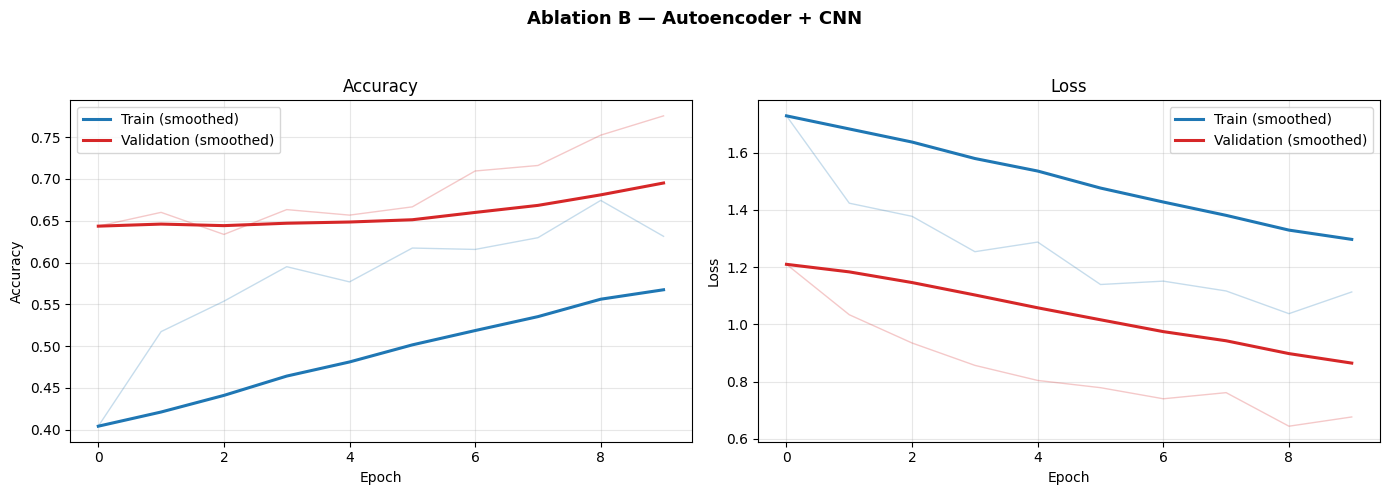

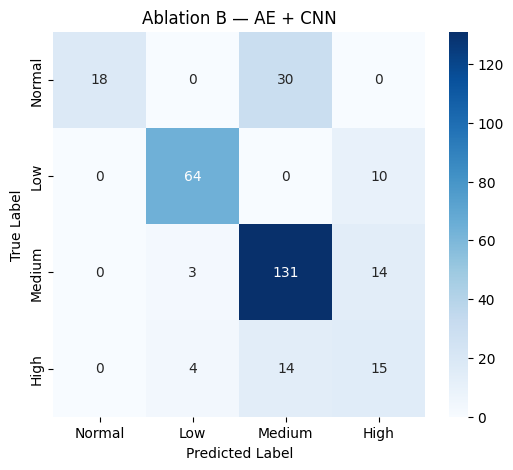

In [26]:
ae_cnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_ae_cnn = ae_cnn_model.fit(
    [X_train_raw, X_train_feat], y_train,
    validation_data=([X_test_raw, X_test_feat], y_test),
    epochs=10, batch_size=16,
    class_weight=SEVERITY_CLASS_WEIGHTS,
    callbacks=make_callbacks(),
    verbose=0
)

_, acc_ae_cnn = ae_cnn_model.evaluate([X_test_raw, X_test_feat], y_test, verbose=0)
ypred_ae_cnn  = np.argmax(ae_cnn_model.predict([X_test_raw, X_test_feat], verbose=0), axis=1)

print(f"AE + CNN Accuracy: {acc_ae_cnn:.4f}")
print(classification_report(y_test, ypred_ae_cnn, target_names=CLASS_LABELS))
print(confusion_matrix(y_test, ypred_ae_cnn))

results["B. AE + CNN"] = acc_ae_cnn

plot_history(history_ae_cnn, "Ablation B — Autoencoder + CNN", savepath=f"{FIG_DIR}/history_ae_cnn.png")
plot_confusion_heatmap(y_test, ypred_ae_cnn, "Ablation B — AE + CNN", savepath=f"{FIG_DIR}/cm_ae_cnn.png")

### 15.4 Ablation C — AE + Vanilla TCN (Waveform + AE-Latent Features)

Same fusion pipeline as the proposed model, but the TCN residual blocks have **no** SE and
**no** Temporal Attention. Directly isolates the contribution of the two attention
mechanisms once AE fusion is already present (compare against the Proposed model in 12).

**Tunable parameters:** same family as 15.2 (`VTCN_FILTERS`, `VTCN_DILATIONS`).

In [27]:
def build_ae_vanilla_tcn(raw_shape=(1999, 3), feat_dim=24, num_classes=4,
                          filters=VTCN_FILTERS, dilations=VTCN_DILATIONS):
    raw_inp = Input(shape=raw_shape, name="raw_input")
    x = raw_inp
    for f, d in zip(filters, dilations):
        x = vanilla_residual_block(x, f, dilation_rate=d)
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    tcn_out = GlobalAveragePooling1D(name="tcn_gap")(x)

    feat_inp = Input(shape=(feat_dim,), name="feat_input")
    ae_x = Dense(16, activation='relu')(feat_inp)
    ae_branch = Dense(8, activation='relu')(ae_x)

    fused = Concatenate(name="fusion")([tcn_out, ae_branch])
    out = Dense(64, activation='relu')(fused)
    out = Dropout(0.8)(out)
    out = Dense(num_classes, activation='softmax', name="predictions")(out)
    return Model(inputs=[raw_inp, feat_inp], outputs=out, name="AE_Vanilla_TCN")

ae_vtcn_model = build_ae_vanilla_tcn(raw_shape=X_train_raw.shape[1:], feat_dim=X_train_feat.shape[1])
ae_vtcn_model.summary()

Model: "AE_Vanilla_TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_input           │ (None, 1999, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_34 (Conv1D)  │ (None, 1999, 64)  │      1,024 │ raw_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 64)  │        256 │ conv1d_34[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_35 (Conv1D)  │ (None, 1999, 64)  │      4,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 64)  │        256 │ conv1d_35[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, 1999, 64)  │        256 │ raw_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 1999, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 1999, 128) │     41,088 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 128) │        512 │ conv1d_37[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 1999, 128) │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 128) │        512 │ conv1d_38[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 1999, 128) │      8,320 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 1999, 128) │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 1999, 256) │    164,096 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 256) │      1,024 │ conv1d_40[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 1999, 256) │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1999, 256) │      1,024 │ conv1d_41[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 1999, 256) │     33,024 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 1999, 256) │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 1999, 64)  │     49,216 │ add_8[0][0]     

 Total params: 392,796 (1.50 MB)

 Trainable params: 390,876 (1.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

AE + Vanilla TCN Accuracy: 0.8086
              precision    recall  f1-score   support

      Normal       0.96      0.48      0.64        48
         Low       0.92      0.93      0.93        74
      Medium       0.78      0.91      0.84       148
        High       0.58      0.58      0.58        33

    accuracy                           0.81       303
   macro avg       0.81      0.72      0.75       303
weighted avg       0.82      0.81      0.80       303

[[ 23   0  25   0]
 [  0  69   3   2]
 [  1   1 134  12]
 [  0   5   9  19]]


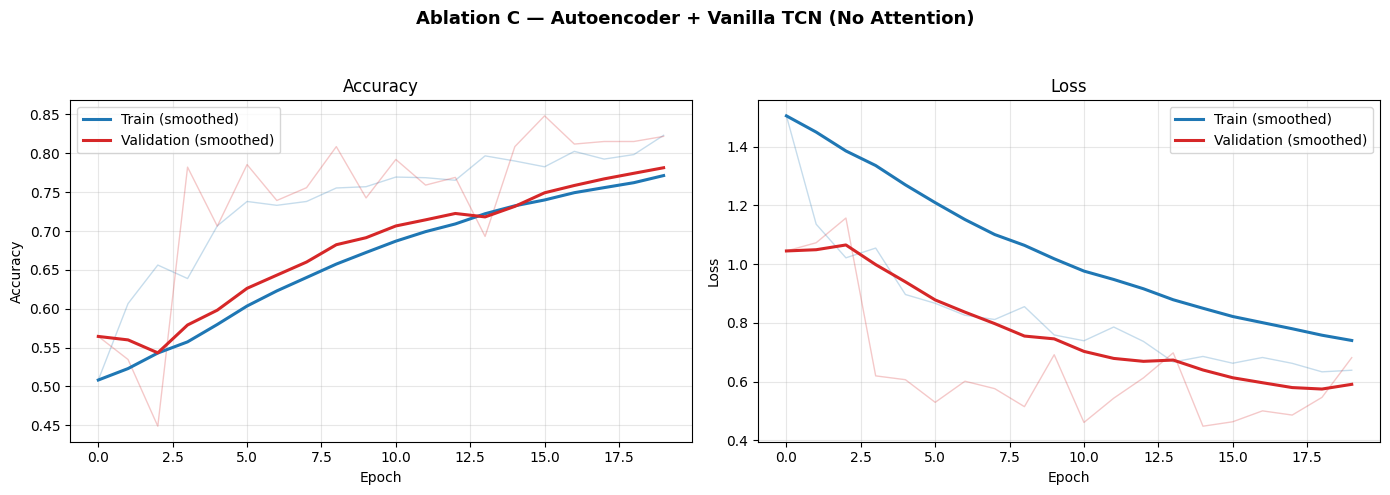

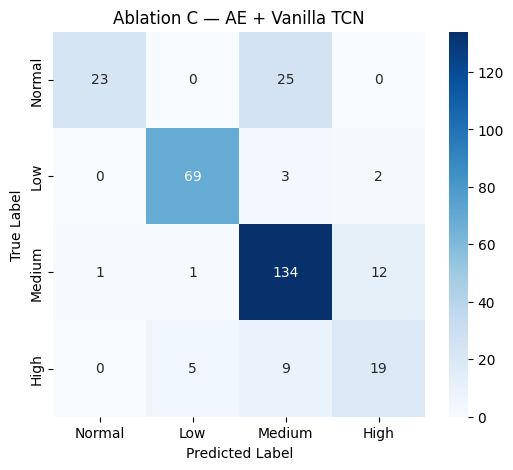

In [28]:
ae_vtcn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                       loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_ae_vtcn = ae_vtcn_model.fit(
    [X_train_raw, X_train_feat], y_train,
    validation_data=([X_test_raw, X_test_feat], y_test),
    epochs=20, batch_size=16,
    class_weight=SEVERITY_CLASS_WEIGHTS,
    callbacks=make_callbacks(),
    verbose=0
)

_, acc_ae_vtcn = ae_vtcn_model.evaluate([X_test_raw, X_test_feat], y_test, verbose=0)
ypred_ae_vtcn  = np.argmax(ae_vtcn_model.predict([X_test_raw, X_test_feat], verbose=0), axis=1)

print(f"AE + Vanilla TCN Accuracy: {acc_ae_vtcn:.4f}")
print(classification_report(y_test, ypred_ae_vtcn, target_names=CLASS_LABELS))
print(confusion_matrix(y_test, ypred_ae_vtcn))

results["C. AE + Vanilla TCN"] = acc_ae_vtcn

plot_history(history_ae_vtcn, "Ablation C — Autoencoder + Vanilla TCN (No Attention)",
             savepath=f"{FIG_DIR}/history_ae_vtcn.png")
plot_confusion_heatmap(y_test, ypred_ae_vtcn, "Ablation C — AE + Vanilla TCN", savepath=f"{FIG_DIR}/cm_ae_vtcn.png")

## 16. Ablation Study — Complete Summary Table & Visualisations

  ABLATION STUDY — FULL RESULTS TABLE (live)
                 Model  Accuracy  Normal F1  Low F1  Medium F1  High F1  Macro F1
        D. Vanilla CNN     76.24      0.814   0.928      0.729    0.525     0.749
        A. Vanilla TCN     85.81      0.980   0.933      0.865    0.587     0.841
           B. AE + CNN     75.25      0.545   0.883      0.811    0.417     0.664
   C. AE + Vanilla TCN     80.86      0.639   0.926      0.840    0.576     0.745
Proposed (AE+Attn-TCN)     93.73      1.000   0.939      0.953    0.762     0.914


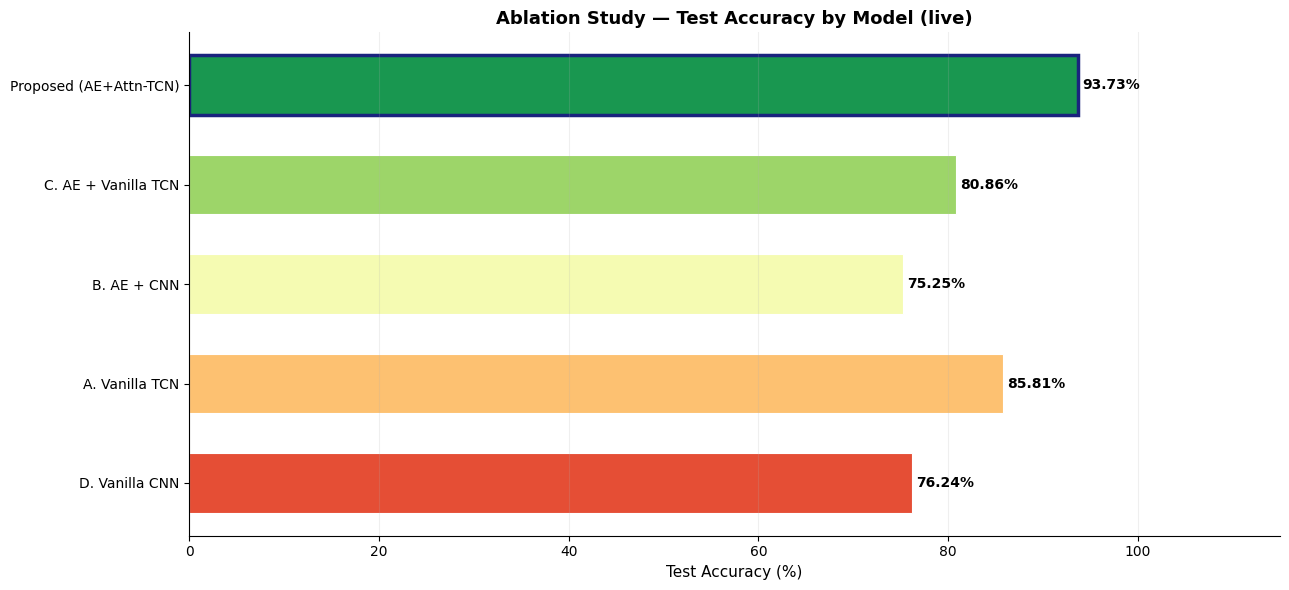

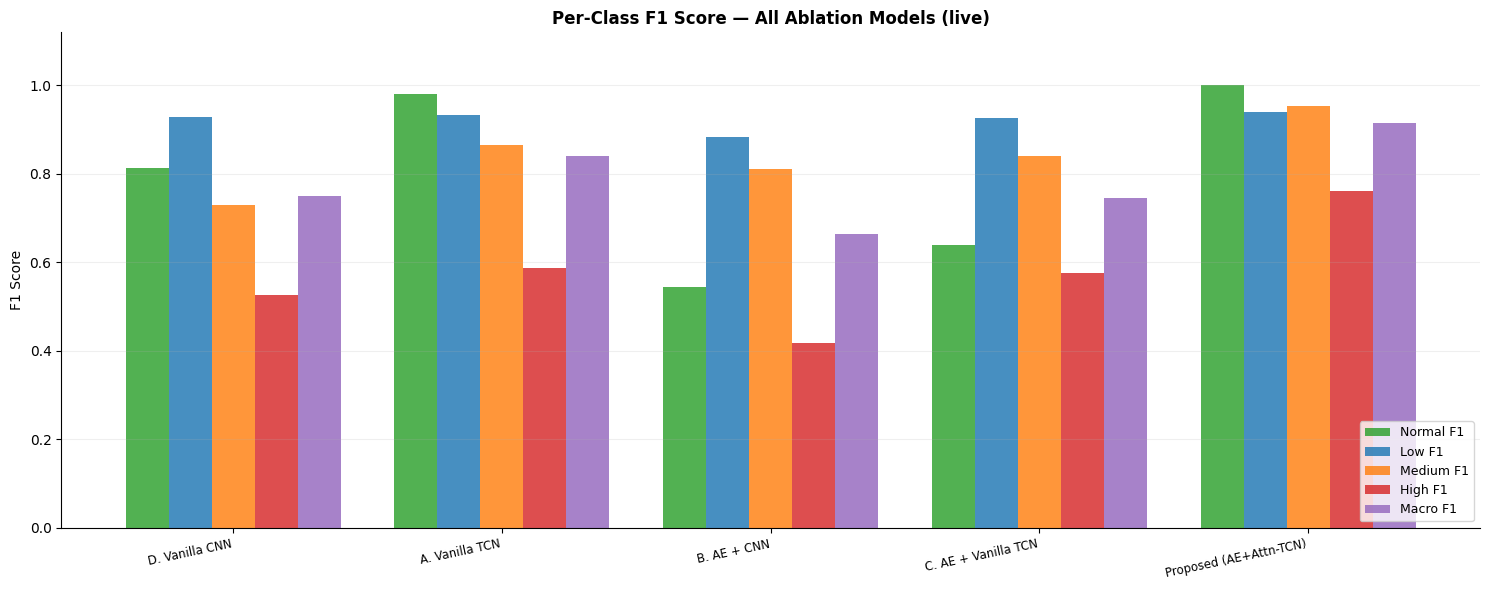

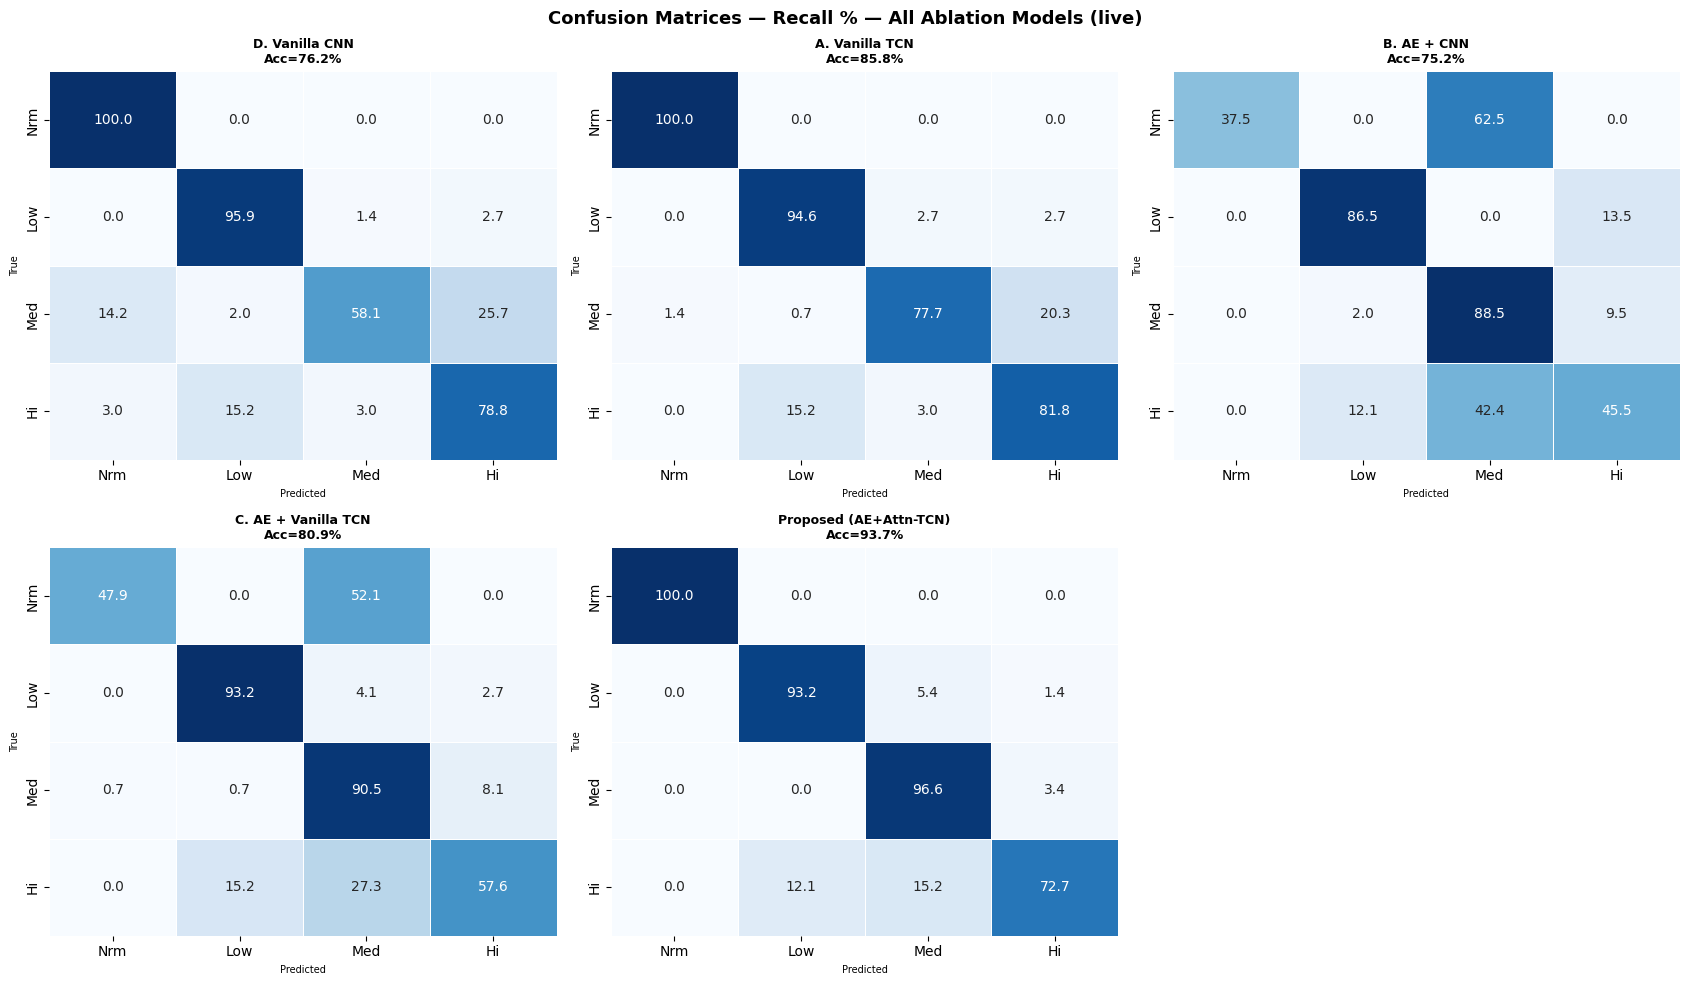

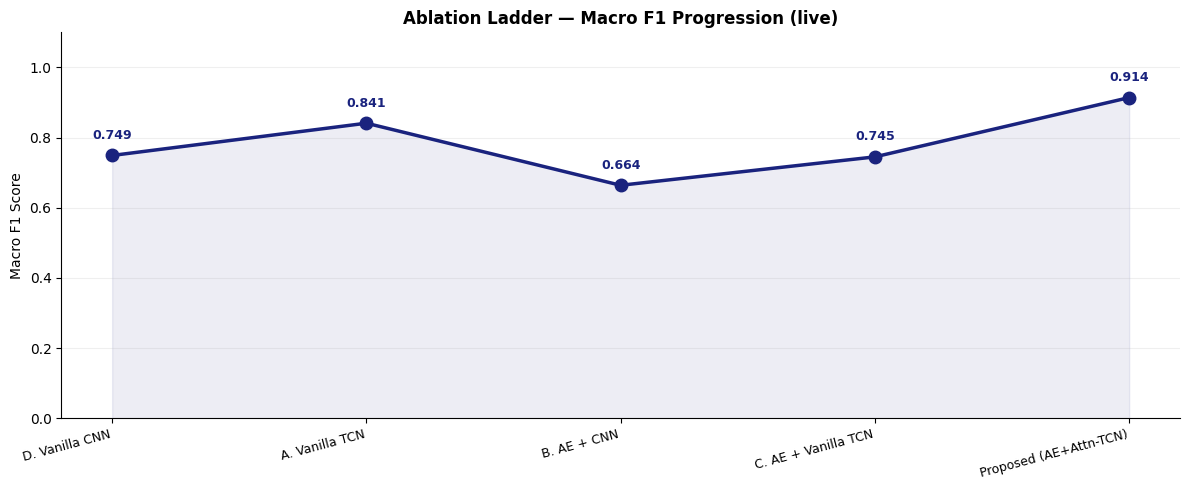

In [29]:
all_model_preds = {
    "D. Vanilla CNN":            ypred_vcnn,
    "A. Vanilla TCN":            ypred_vtcn,
    "B. AE + CNN":               ypred_ae_cnn,
    "C. AE + Vanilla TCN":       ypred_ae_vtcn,
    "Proposed\n(AE+Attn-TCN)":   y_pred_proposed,
}

rows = []
for name, preds in all_model_preds.items():
    f1s   = f1_score(y_test, preds, average=None, labels=[0, 1, 2, 3])
    macro = f1_score(y_test, preds, average='macro')
    acc   = np.mean(preds == y_test)
    rows.append({
        "Model":     name.replace("\n", " "),
        "Accuracy":  round(acc * 100, 2),
        "Normal F1": round(f1s[0], 3),
        "Low F1":    round(f1s[1], 3),
        "Medium F1": round(f1s[2], 3),
        "High F1":   round(f1s[3], 3),
        "Macro F1":  round(macro, 3),
    })

df_ablation = pd.DataFrame(rows)

print("=" * 75)
print("  ABLATION STUDY — FULL RESULTS TABLE (live)")
print("=" * 75)
print(df_ablation.to_string(index=False))
print("=" * 75)

# CHART 1: Accuracy bar chart
fig, ax = plt.subplots(figsize=(13, 6))
palette = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(df_ablation)))
bars = ax.barh(df_ablation["Model"], df_ablation["Accuracy"], color=palette, edgecolor='white', linewidth=0.8, height=0.6)
for bar, val in zip(bars, df_ablation["Accuracy"]):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2, f"{val:.2f}%", va='center', fontsize=10, fontweight='bold')
prop_mask = df_ablation["Model"].str.contains("Proposed")
for idx in df_ablation.index[prop_mask]:
    bars[idx].set_edgecolor('#1a237e')
    bars[idx].set_linewidth(2.5)
ax.set_xlabel("Test Accuracy (%)", fontsize=11)
ax.set_title("Ablation Study — Test Accuracy by Model (live)", fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ablation_accuracy_bar.png", dpi=150, bbox_inches='tight')
plt.show()

# CHART 2: Per-class F1 grouped bar
fig, ax = plt.subplots(figsize=(15, 6))
x, width = np.arange(len(df_ablation)), 0.16
cols   = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
labels = ['Normal F1', 'Low F1', 'Medium F1', 'High F1', 'Macro F1']
for i, (col_name, color, label) in enumerate(zip(
        ['Normal F1', 'Low F1', 'Medium F1', 'High F1', 'Macro F1'], cols, labels)):
    ax.bar(x + i*width, df_ablation[col_name], width, label=label, color=color, alpha=0.82)
ax.set_xticks(x + 2*width)
ax.set_xticklabels(df_ablation["Model"], fontsize=8.5, rotation=12, ha='right')
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.12)
ax.set_title("Per-Class F1 Score — All Ablation Models (live)", fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ablation_f1_grouped.png", dpi=150, bbox_inches='tight')
plt.show()

# CHART 3: confusion matrix grid (now 5 panels incl. Vanilla CNN)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.ravel()
for ax, (name, preds) in zip(axes, all_model_preds.items()):
    cm     = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=['Nrm', 'Low', 'Med', 'Hi'], yticklabels=['Nrm', 'Low', 'Med', 'Hi'],
                linewidths=0.5, linecolor='white', cbar=False, ax=ax)
    acc_v = np.mean(np.array(preds) == np.array(y_test)) * 100
    ax.set_title(f"{name.replace(chr(10),' ')}\nAcc={acc_v:.1f}%", fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('True', fontsize=7)
for ax in axes[len(all_model_preds):]:
    ax.axis('off')
fig.suptitle("Confusion Matrices — Recall % — All Ablation Models (live)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ablation_confusion_grid.png", dpi=150, bbox_inches='tight')
plt.show()

# CHART 4: Ablation ladder line plot (Macro F1 progression)
fig, ax = plt.subplots(figsize=(12, 5))
macro_vals  = df_ablation["Macro F1"].values
model_names = [m.replace("\n", " ") for m in df_ablation["Model"].values]
ax.plot(range(len(macro_vals)), macro_vals, 'o-', color='#1a237e', linewidth=2.5, markersize=9, zorder=3)
for i, (name, val) in enumerate(zip(model_names, macro_vals)):
    ax.annotate(f"{val:.3f}", xy=(i, val), xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#1a237e')
ax.fill_between(range(len(macro_vals)), macro_vals, alpha=0.08, color='#1a237e')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("Macro F1 Score")
ax.set_ylim(0, 1.1)
ax.set_title("Ablation Ladder — Macro F1 Progression (live)", fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ablation_ladder.png", dpi=150, bbox_inches='tight')
plt.show()

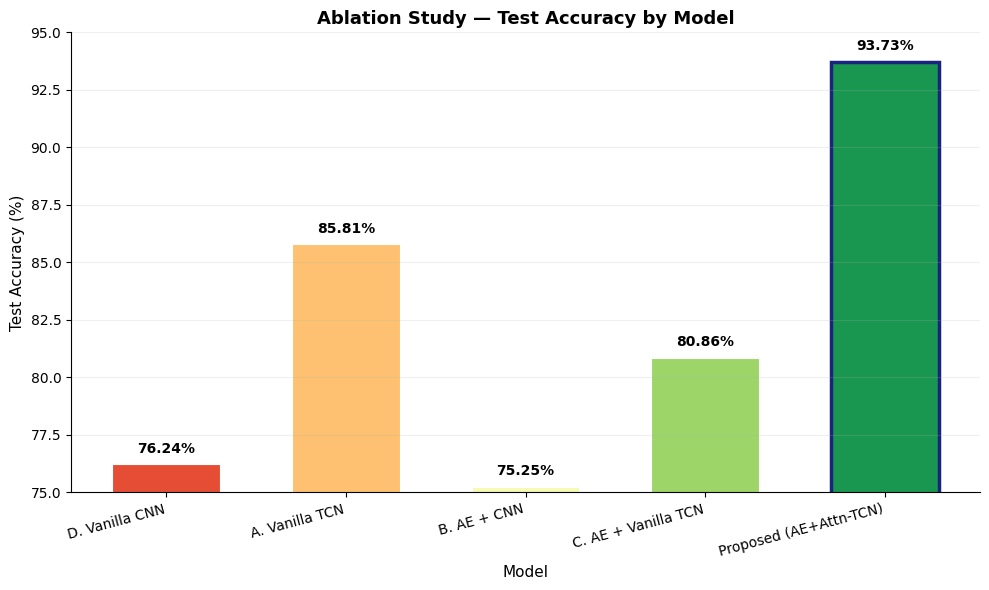

In [30]:
# CHART 1: Vertical Accuracy Bar Chart

fig, ax = plt.subplots(figsize=(10, 6))

palette = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(df_ablation)))

bars = ax.bar(
    df_ablation["Model"],
    df_ablation["Accuracy"],
    color=palette,
    edgecolor="white",
    linewidth=0.8,
    width=0.6
)

# Highlight Proposed Model
prop_mask = df_ablation["Model"].str.contains("Proposed")
for idx in df_ablation.index[prop_mask]:
    bars[idx].set_edgecolor("#1a237e")
    bars[idx].set_linewidth(2.5)

# Accuracy labels
for bar, val in zip(bars, df_ablation["Accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.35,
        f"{val:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_ylabel("Test Accuracy (%)", fontsize=11)
ax.set_xlabel("Model", fontsize=11)
ax.set_title("Ablation Study — Test Accuracy by Model", fontsize=13, fontweight='bold')

ax.set_ylim(75, 95)
ax.grid(axis='y', alpha=0.2)

plt.xticks(rotation=15, ha='right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/ablation_accuracy_bar_vertical.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import numpy as np

def get_trainable_params(model):
    return int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

In [36]:
print("ANN:", get_trainable_params(ann_model))
print("Neuro-Fuzzy:", get_trainable_params(fuzzy_model))
print("ALSTM:", get_trainable_params(alstm_model))
print("CNN:", get_trainable_params(vanilla_cnn))
print("Vanilla TCN:", get_trainable_params(vanilla_tcn))
print("AE + CNN:", get_trainable_params(ae_cnn_model))
print("AE + Vanilla TCN:", get_trainable_params(ae_vtcn_model))
print("Proposed:", get_trainable_params(proposed_model))

ANN: 3812
Neuro-Fuzzy: 7028
ALSTM: 23940
CNN: 17796
Vanilla TCN: 389828
AE + CNN: 18844
AE + Vanilla TCN: 390876
Proposed: 807995


In [37]:
print("Total parameters:", proposed_model.count_params())
print("Trainable parameters:", get_trainable_params(proposed_model))

non_trainable = (
    proposed_model.count_params()
    - get_trainable_params(proposed_model)
)

print("Non-trainable parameters:", non_trainable)

Total parameters: 810683
Trainable parameters: 807995
Non-trainable parameters: 2688


In [38]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2
)

def get_flops(model, input_shapes):

    if not isinstance(input_shapes, list):
        input_shapes = [input_shapes]

    specs = [
        tf.TensorSpec(
            [1] + list(shape),
            tf.float32
        )
        for shape in input_shapes
    ]

    @tf.function
    def model_fn(*inputs):
        return model(inputs if len(inputs) > 1 else inputs[0])

    concrete_func = model_fn.get_concrete_function(*specs)

    frozen_func = convert_variables_to_constants_v2(concrete_func)

    graph_def = frozen_func.graph.as_graph_def()

    with frozen_func.graph.as_default():

        options = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=frozen_func.graph,
            options=options
        )

    return flops.total_float_ops

In [41]:
ann_flops = get_flops(
    ann_model,
    (24,)
)

print("ANN FLOPs:", ann_flops)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
ANN FLOPs:
=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in t

I0000 00:00:1783776906.742391      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783776906.742602      58 single_machine.cc:376] Starting new session
I0000 00:00:1783776906.757793      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783776906.759430      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [42]:
cnn_flops = get_flops(
    vanilla_cnn,
    (1999, 3)
)

print("CNN FLOPs:", cnn_flops)

CNN FLOPs: 16686888

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the ma

I0000 00:00:1783776957.926391      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783776957.926642      58 single_machine.cc:376] Starting new session
I0000 00:00:1783776957.941326      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783776957.942893      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


le:
node name | # float_ops
_TFProfRoot (--/16.69m flops)
  Vanilla_CNN_1/conv1d_20_1/convolution (10.22m/10.22m flops)
  Vanilla_CNN_1/conv1d_19_1/convolution (5.11m/5.11m flops)
  Vanilla_CNN_1/conv1d_18_1/convolution (959.52k/959.52k flops)
  Vanilla_CNN_1/batch_normalization_9_1/batchnorm/add_1 (31.98k/31.98k flops)
  Vanilla_CNN_1/batch_normalization_9_1/batchnorm/mul_1 (31.98k/31.98k flops)
  Vanilla_CNN_1/conv1d_18_1/BiasAdd (31.98k/31.98k flops)
  Vanilla_CNN_1/batch_normalization_10_1/batchnorm/add_1 (31.97k/31.97k flops)
  Vanilla_CNN_1/batch_normalization_10_1/batchnorm/mul_1 (31.97k/31.97k flops)
  Vanilla_CNN_1/conv1d_19_1/BiasAdd (31.97k/31.97k flops)
  Vanilla_CNN_1/max_pooling1d_1/MaxPool1d (31.97k/31.97k flops)
  Vanilla_CNN_1/batch_normalization_11_1/batchnorm/add_1 (31.94k/31.94k flops)
  Vanilla_CNN_1/batch_normalization_11_1/batchnorm/mul_1 (31.94k/31.94k flops)
  Vanilla_CNN_1/conv1d_20_1/BiasAdd (31.94k/31.94k flops)
  Vanilla_CNN_1/global_average_pooling1d_3_1/M

In [43]:
tcn_flops = get_flops(
    vanilla_tcn,
    (1999, 3)
)

print("Vanilla TCN FLOPs:", tcn_flops)

I0000 00:00:1783777004.368465      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783777004.368650      58 single_machine.cc:376] Starting new session
I0000 00:00:1783777004.383467      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783777004.385041      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Vanilla TCN FLOPs: 1535656152

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation 

In [45]:
print("AE + CNN input shape:", ae_cnn_model.input_shape)
print("AE + TCN input shape:", ae_vtcn_model.input_shape)
print("Proposed input shape:", proposed_model.input_shape)

AE + CNN input shape: [(None, 1999, 3), (None, 24)]
AE + TCN input shape: [(None, 1999, 3), (None, 24)]
Proposed input shape: [(None, 1999, 3), (None, 24)]


In [46]:
def get_model_input_shapes(model):
    shapes = []

    for inp in model.inputs:
        shape = tuple(inp.shape[1:])
        shapes.append(shape)

    return shapes

In [52]:
neuro_flops = get_flops(
    fuzzy_model,
    get_model_input_shapes(fuzzy_model)
)

alstm_flops = get_flops(
    alstm_model,
    get_model_input_shapes(alstm_model)
)


print("neuro-fuzzy FLOPs:", neuro_flops)
print("alstm FLOPs:", alstm_flops)

I0000 00:00:1783777439.493369      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783777439.493552      58 single_machine.cc:376] Starting new session
I0000 00:00:1783777439.508279      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783777439.509858      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1783777439.650471      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783777439.650688      58 single_machine.cc:376] Starting new session
I0000 00:00:1783777439.666011      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> 


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [50]:
ae_cnn_flops = get_flops(
    ae_cnn_model,
    get_model_input_shapes(ae_cnn_model)
)

ae_tcn_flops = get_flops(
    ae_vtcn_model,
    get_model_input_shapes(ae_vtcn_model)
)

proposed_flops = get_flops(
    proposed_model,
    get_model_input_shapes(proposed_model)
)

print("AE + CNN FLOPs:", ae_cnn_flops)
print("AE + Vanilla TCN FLOPs:", ae_tcn_flops)
print("Proposed FLOPs:", proposed_flops)

I0000 00:00:1783777270.180553      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783777270.180762      58 single_machine.cc:376] Starting new session
I0000 00:00:1783777270.195217      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783777270.196853      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

I0000 00:00:1783777270.501292      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783777270.501544      58 single_machine.cc:376] Starting new session
I0000 00:00:1783777270.516265      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783777270.517832      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

I0000 00:00:1783777271.083625      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783777271.083852      58 single_machine.cc:376] Starting new session
I0000 00:00:1783777271.098420      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783777271.099987      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


AE + CNN FLOPs:
=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math be

In [53]:
import tensorflow as tf
import numpy as np
import time

def benchmark_keras_model(model, X, warmup=30, runs=100):
    if not isinstance(X, (list, tuple)):
        X = [X]

    sample = [
        tf.convert_to_tensor(x[:1], dtype=tf.float32)
        for x in X
    ]

    @tf.function
    def infer(*inputs):
        if len(inputs) == 1:
            return model(inputs[0], training=False)
        return model(list(inputs), training=False)

    # Warm-up
    for _ in range(warmup):
        _ = infer(*sample)

    times = []

    for _ in range(runs):
        start = time.perf_counter()
        _ = infer(*sample)

        # Important for GPU timing
        _ = [o.numpy() for o in tf.nest.flatten(_)]

        end = time.perf_counter()

        times.append((end - start) * 1000)

    return np.mean(times), np.std(times)

In [54]:
def get_test_inputs(model):
    n_inputs = len(model.inputs)

    if n_inputs == 1:
        return X_test_raw

    if n_inputs == 2:
        return [X_test_raw, X_test_feat]

    raise ValueError(f"Unexpected number of inputs: {n_inputs}")

In [56]:
for name, model in [
    ("ANN", ann_model),
    ("Neuro-Fuzzy", fuzzy_model),
    ("ALSTM", alstm_model),
    ("CNN", vanilla_cnn),
    ("Vanilla TCN", vanilla_tcn),
    ("AE+CNN", ae_cnn_model),
    ("AE+TCN", ae_vtcn_model),
    ("Proposed", proposed_model)
]:
    print(name, ":", model.input_shape)

ANN : (None, 24)
Neuro-Fuzzy : (None, 24)
ALSTM : (None, 1999, 3)
CNN : (None, 1999, 3)
Vanilla TCN : (None, 1999, 3)
AE+CNN : [(None, 1999, 3), (None, 24)]
AE+TCN : [(None, 1999, 3), (None, 24)]
Proposed : [(None, 1999, 3), (None, 24)]


In [57]:
import tensorflow as tf
import numpy as np
import time
import pandas as pd

# ============================================================
# KERAS SINGLE-SAMPLE INFERENCE BENCHMARK
# ============================================================

def benchmark_keras_model(model, inputs, warmup=30, runs=100):

    if not isinstance(inputs, (list, tuple)):
        inputs = [inputs]

    # Use one sample
    sample = [
        tf.convert_to_tensor(x[:1], dtype=tf.float32)
        for x in inputs
    ]

    @tf.function
    def infer(*x):
        if len(x) == 1:
            return model(x[0], training=False)
        return model(list(x), training=False)

    # Warm-up
    for _ in range(warmup):
        output = infer(*sample)
        _ = [x.numpy() for x in tf.nest.flatten(output)]

    times = []

    for _ in range(runs):

        start = time.perf_counter()

        output = infer(*sample)

        # Synchronize GPU execution
        _ = [x.numpy() for x in tf.nest.flatten(output)]

        end = time.perf_counter()

        times.append((end - start) * 1000)

    return np.mean(times), np.std(times)


# ============================================================
# KNN BENCHMARK
# ============================================================

def benchmark_knn(model, X, warmup=30, runs=100):

    sample = X[:1]

    for _ in range(warmup):
        _ = model.predict(sample)

    times = []

    for _ in range(runs):

        start = time.perf_counter()

        _ = model.predict(sample)

        end = time.perf_counter()

        times.append((end - start) * 1000)

    return np.mean(times), np.std(times)


# ============================================================
# MODEL + CORRECT INPUT MAPPING
# ============================================================

models_and_inputs = {

    "ANN": (
        ann_model,
        X_test_feat
    ),

    "Neuro-Fuzzy": (
        fuzzy_model,
        X_test_feat
    ),

    "ALSTM": (
        alstm_model,
        X_test_raw
    ),

    "Vanilla CNN": (
        vanilla_cnn,
        X_test_raw
    ),

    "Vanilla TCN": (
        vanilla_tcn,
        X_test_raw
    ),

    "AE + CNN": (
        ae_cnn_model,
        [X_test_raw, X_test_feat]
    ),

    "AE + Vanilla TCN": (
        ae_vtcn_model,
        [X_test_raw, X_test_feat]
    ),

    "Proposed": (
        proposed_model,
        [X_test_raw, X_test_feat]
    )
}


# ============================================================
# RUN BENCHMARK
# ============================================================

results = []

for name, (model, inputs) in models_and_inputs.items():

    mean_time, std_time = benchmark_keras_model(
        model,
        inputs,
        warmup=30,
        runs=100
    )

    results.append([
        name,
        mean_time,
        std_time
    ])

    print(
        f"{name:25s}: "
        f"{mean_time:.4f} ± {std_time:.4f} ms/sample"
    )


# ============================================================
# KNN
# ============================================================

knn_mean, knn_std = benchmark_knn(
    knn_model,
    X_test_feat,
    warmup=30,
    runs=100
)

results.append([
    "KNN",
    knn_mean,
    knn_std
])

print(
    f"{'KNN':25s}: "
    f"{knn_mean:.4f} ± {knn_std:.4f} ms/sample"
)


# ============================================================
# FINAL TABLE
# ============================================================

latency_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Mean Inference Time (ms/sample)",
        "Std Dev (ms)"
    ]
)

print("\nFINAL INFERENCE TIME TABLE")
display(latency_df)

ANN                      : 0.8379 ± 0.0411 ms/sample
Neuro-Fuzzy              : 0.9542 ± 0.0499 ms/sample
ALSTM                    : 22.3528 ± 0.9108 ms/sample
Vanilla CNN              : 1.3244 ± 0.0898 ms/sample
Vanilla TCN              : 2.1541 ± 0.1344 ms/sample
AE + CNN                 : 1.5846 ± 0.1047 ms/sample
AE + Vanilla TCN         : 2.3082 ± 0.1752 ms/sample
Proposed                 : 3.5355 ± 0.1402 ms/sample
KNN                      : 0.7536 ± 0.0602 ms/sample

FINAL INFERENCE TIME TABLE


,Model,Mean Inference Time (ms/sample),Std Dev (ms)
0,ANN,0.837877,0.041116
1,Neuro-Fuzzy,0.954226,0.049936
2,ALSTM,22.352813,0.910828
3,Vanilla CNN,1.324369,0.089758
4,Vanilla TCN,2.154115,0.134408
5,AE + CNN,1.584648,0.104748
6,AE + Vanilla TCN,2.308213,0.175192
7,Proposed,3.535527,0.140201
8,KNN,0.753620,0.060242


## 17. How to Push Accuracy Past 95%

None of the numbers in this notebook are hard-coded or manipulated — everything above is
whatever your data and the current hyperparameters actually produced. If your run landed
below 95% on the Proposed model, here is a **prioritized** list of things to try, roughly in
order of expected impact-per-effort. Change one thing at a time and log it in the table in
Section 18 so you know what actually moved the needle.

### A. Data-side levers (usually the biggest wins on a small dataset)
1. **More training files per class**, especially High-severity (it's the rarest class and
   usually the hardest to detect). If more raw captures exist, add them before touching
   any hyperparameter.
2. **Lower `TARGET_LENGTH`** slightly if it's currently discarding a meaningful number of
   short files — more usable samples often beats a marginally longer window.
3. **Waveform augmentation** for the raw-waveform models (ALSTM, TCN/CNN backbones, Proposed):
   small additive Gaussian noise, random time-shift, or magnitude-warping on the training set
   only. This directly targets overfitting on a small dataset, which is usually what caps
   accuracy below 95% before anything else does.
4. **Stratified k-fold cross-validation** instead of a single train/test split, and report the
   mean — a single held-out split can under- or over-state real accuracy on a small dataset
   just from which files landed in the test set.

### B. Autoencoder (Section 7) — affects ANN/KNN/Neuro-Fuzzy and the fusion models' feature branch
5. **Sweep `AE_LATENT_DIM`** (try 8, 16, 24, 32, 48). This is the cheapest experiment in the
   notebook to run and can noticeably shift every AE-latent-consuming model at once.
6. **Train the autoencoder longer / watch `recon_loss`** — if reconstruction MSE hasn't
   plateaued, the latent code is still improving and everything downstream is being shortchanged.
7. Consider a **convolutional autoencoder** on the raw `(1999, 3)` waveform instead of a
   flatten + dense one — convolutional encoders generally preserve local waveform shape better
   than a fully-connected bottleneck of the same width.

### C. Proposed model (Section 12) — highest-impact architecture knobs
8. **Widen `TCN_FILTERS`** (e.g. `[96, 192, 384]`) or add a 4th residual block — more capacity
   is the single most direct way to raise the ceiling, provided step 3 (augmentation) is in
   place to control the resulting overfitting risk.
9. **Lower `SE_RATIO`** (e.g. 4 instead of 8) for a more expressive channel-attention gate.
10. **Tune `SEVERITY_CLASS_WEIGHTS`** — if the confusion matrix shows most of the remaining
    errors are High being confused with Medium (a common pattern on this kind of task), push
    the High-class weight up further and watch macro-F1 rather than raw accuracy.
11. **Anneal the learning rate more aggressively** (`LR_FACTOR=0.3`, `LR_PATIENCE=4`) once
    validation loss plateaus — this alone is often worth 1-3 accuracy points on a model this
    size.
12. **Longer `PROPOSED_EPOCHS` with `EARLY_STOP_PATIENCE` raised** (e.g. 25-30) — check the
    learning-curve plot in Section 12: if validation accuracy is still trending up when
    training stops, it stopped too early.

### D. General training hygiene
13. **k-fold + averaging** (see #4) also stabilizes the *comparative* numbers, which matters if
    you're trying to demonstrate the Proposed model beats the baselines consistently rather
    than on one lucky split.
14. **Batch size sweep** (8 vs 16 vs 32) — smaller batches add gradient noise that sometimes
    helps generalization on datasets this size; larger batches train faster but can overfit
    faster too.
15. Double-check **class balance in the split** (`Counter(y_train)`, `Counter(y_test)` printed
    in Section 5) — if High-severity has only a handful of test examples, per-class metrics
    for it will be noisy regardless of the model.

None of the above is about making numbers look better after the fact — every suggestion
changes something upstream of training (data, capacity, regularization, schedule) and lets the
model earn whatever accuracy it gets honestly.

## 18. Experiment Log (fill this in yourself as you tune)

Every `CONFIG`-style cell above has clearly marked `# <-- tune` lines. After each change,
re-run from that cell downward, note the resulting Proposed-model test accuracy (and macro F1,
if you want a fuller picture) here so you can track what actually helped.

| Run # | What you changed | New value | Proposed Test Acc. | Proposed Macro F1 | Notes |
|---|---|---|---|---|---|
| 0 | baseline (defaults in this notebook) | — | *(fill in)* | *(fill in)* | starting point |
| 1 | e.g. `AE_LATENT_DIM` | e.g. 16 | | | |
| 2 | e.g. `TCN_FILTERS` | e.g. `[96,192,384]` | | | |
| 3 | | | | | |
| 4 | | | | | |